<a href="https://colab.research.google.com/github/micheleperrone23/shot-predictor-serie-a-2026/blob/main/SerieA_Shot_Predictor_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [61]:
import pandas as pd
import io #  Dice a Pandas: "Ehi, non cercare un file nel computer, fai finta che questo blocco di testo sia un file e leggilo".
import re # I dati presi dal sito sono "sporchi". A volte tra il nome del giocatore e la squadra c'è un tasto TAB, altre volte ci sono 3 o 4 spazi.
from scipy.stats import poisson

dati_completi = """Player Shooting 2025-2026 Serie A
Hide non-qualifiers for rate stats
GlossaryToggle Per90 Stats
Standard
Rk	Player	Nation	Pos	Squad	Age	Born	90s	Gls	Sh	SoT	SoT%	Sh/90	SoT/90	G/Sh	G/SoT	PK	PKatt	Matches
1	Zakaria Aboukhlal	ma MAR	MF	Torino	26-069	2000	5.7	0	7	2	28.6	1.23	0.35	0.00	0.00	0	0	Matches
2	Francesco Acerbi	it ITA	DF	Inter	38-077	1988	13.3	0	3	1	33.3	0.23	0.08	0.00	0.00	0	0	Matches
3	Che Adams	sct SCO	FW	Torino	29-289	1996	20.3	5	48	14	29.2	2.37	0.69	0.10	0.36	0	0	Matches
4	Jayden Addai	nl NED	MF	Como	20-245	2005	7.6	3	13	6	46.2	1.71	0.79	0.23	0.50	0	0	Matches
5	Vasilije Adžić	me MNE	MF	Juventus	19-351	2006	1.9	1	6	4	66.7	3.16	2.11	0.17	0.25	0	0	Matches
6	Michel Aebischer	ch SUI	MF	Pisa	29-112	1997	29.5	1	17	3	17.6	0.58	0.10	0.06	0.33	0	0	Matches
7	Honest Ahanor	it ITA	DF	Atalanta	18-064	2008	12.0	0	10	2	20.0	0.83	0.17	0.00	0.00	0	0	Matches
8	Junior Ajayi	ci CIV	FW	Hellas Verona	21-199	2004	0.0	0	0	0		0.00	0.00			0	0	Matches
9	Manuel Akanji	ch SUI	DF	Inter	30-283	1995	30.3	2	23	6	26.1	0.76	0.20	0.09	0.33	0	0	Matches
10	Ebenezer Akinsanmiro	ng NGA	MF	Pisa	21-154	2004	13.2	0	13	3	23.1	0.98	0.23	0.00	0.00	0	0	Matches
11	Jean-Daniel Akpa-Akpro	ci CIV	MF	Hellas Verona	33-199	1992	13.5	1	13	4	30.8	0.96	0.30	0.08	0.25	0	0	Matches
12	Al-Musrati	ly LBY	MF	Hellas Verona	30-022	1996	9.0	0	8	1	12.5	0.89	0.11	0.00	0.00	0	0	Matches
13	Agustín Albarracín	uy URU	FW	Cagliari	20-242	2005	0.2	0	0	0		0.00	0.00			0	0	Matches
14	Raúl Albiol	es ESP	DF	Pisa	40-236	1985	5.6	0	1	0	0.0	0.18	0.00	0.00		0	0	Matches
15	Pontus Almqvist	se SWE	MF	Parma	26-292	1999	4.6	0	3	2	66.7	0.66	0.44	0.00	0.00	0	0	Matches
16	Giuseppe Ambrosino	it ITA	FW	Napoli	22-230	2003	0.4	0	0	0		0.00	0.00			0	0	Matches
17	Amorim	br BRA	MF	Genoa	20-345	2005	2.7	0	2	0	0.0	0.73	0.00	0.00		0	0	Matches
18	Nícolas Andrade	br BRA	GK	Pisa	38-016	1988	6.0	0	0	0		0.00	0.00			0	0	Matches
19	Angeliño	es ESP	MF	Roma	29-114	1997	4.6	0	5	2	40.0	1.08	0.43	0.00	0.00	0	0	Matches
20	Samuele Angori	it ITA	MF	Pisa	22-203	2003	25.6	0	13	2	15.4	0.51	0.08	0.00	0.00	0	0	Matches
21	Faustino Anjorin	eng ENG	MF	Torino	24-156	2001	3.2	0	4	1	25.0	1.25	0.31	0.00	0.00	0	0	Matches
22	Antonio Arena	it ITA	FW	Roma	17-077	2009	0.3	0	2	0	0.0	7.83	0.00	0.00		0	0	Matches
23	Juan Arizala	co COL	MF	Udinese	20-200	2005	1.2	0	1	1	100.0	0.80	0.80	0.00	0.00	0	0	Matches
24	Kristjan Asllani	al ALB	MF	Torino	24-050	2002	12.5	0	20	4	20.0	1.59	0.32	0.00	0.00	0	1	Matches
25	Zachary Athekame	ch SUI	MF,DF	Milan	21-136	2004	7.1	1	8	2	25.0	1.13	0.28	0.13	0.50	0	0	Matches
Rk	Player	Nation	Pos	Squad	Age	Born	90s	Gls	Sh	SoT	SoT%	Sh/90	SoT/90	G/Sh	G/SoT	PK	PKatt	Matches
26	Arthur Atta	fr FRA	MF	Udinese	23-104	2003	24.5	5	51	19	37.3	2.08	0.78	0.10	0.26	0	0	Matches
27	Emil Audero	id IDN	GK	Cremonese	29-100	1997	30.0	0	0	0		0.00	0.00			0	0	Matches
28	Carlos Augusto	br BRA	DF,MF	Inter	27-111	1999	16.3	1	15	4	26.7	0.92	0.25	0.07	0.25	0	0	Matches
29	Yann Aurel Bisseck	de GER	DF	Inter	25-150	2000	18.4	3	24	11	45.8	1.31	0.60	0.13	0.27	0	0	Matches
30	Neil El Aynaoui	ma MAR	MF	Roma	24-300	2001	9.2	1	5	4	80.0	0.54	0.43	0.20	0.25	0	0	Matches
31	Leon Bailey	jm JAM	FW	Roma	28-262	1997	2.1	0	3	1	33.3	1.45	0.48	0.00	0.00	0	0	Matches
32	Darryl Bakola	fr FRA	MF	Sassuolo	18-149	2007	1.1	0	2	0	0.0	1.76	0.00	0.00		0	0	Matches
33	Luís Balbo	ve VEN	DF	Fiorentina	20-031	2006	2.0	0	0	0		0.00	0.00			0	0	Matches
34	Tommaso Baldanzi	it ITA	MF	Genoa	23-036	2003	3.7	0	8	3	37.5	2.14	0.80	0.00	0.00	0	0	Matches
35	Tommaso Baldanzi	it ITA	FW,MF	Roma	23-036	2003	4.3	1	11	4	36.4	2.56	0.93	0.09	0.25	0	0	Matches
36	Lameck Banda	zm ZAM	MF,FW	Lecce	25-089	2001	16.5	3	31	8	25.8	1.88	0.49	0.10	0.38	0	0	Matches
37	Tommaso Barbieri	it ITA	MF	Cremonese	23-245	2002	17.0	0	13	2	15.4	0.77	0.12	0.00	0.00	0	0	Matches
38	Nicolò Barella	it ITA	MF	Inter	29-080	1997	25.9	3	31	5	16.1	1.20	0.19	0.10	0.60	0	0	Matches
39	Davide Bartesaghi	it ITA	MF,DF	Milan	20-120	2005	24.2	2	20	6	30.0	0.82	0.25	0.10	0.33	0	0	Matches
40	Federico Baschirotto	it ITA	DF	Cremonese	29-220	1996	28.0	2	12	5	41.7	0.43	0.18	0.17	0.40	0	0	Matches
41	Toma Bašić	hr CRO	MF	Lazio	29-154	1996	15.3	2	28	11	39.3	1.83	0.72	0.07	0.18	0	0	Matches
42	Alessandro Bastoni	it ITA	DF	Inter	27-015	1999	23.5	1	17	8	47.1	0.72	0.34	0.06	0.13	0	0	Matches
43	Martin Baturina	hr CRO	MF,FW	Como	23-071	2003	14.2	6	20	7	35.0	1.40	0.49	0.30	0.86	0	0	Matches
44	Vakoun Bayo	ci CIV	FW	Udinese	29-108	1997	4.8	0	13	2	15.4	2.70	0.42	0.00	0.00	0	0	Matches
45	Tjaš Begić	si SVN	MF	Parma	22-302	2003	0.0	0	0	0		0.00	0.00			0	0	Matches
46	Reda Belahyane	ma MAR	MF	Lazio	21-331	2004	5.8	0	1	1	100.0	0.17	0.17	0.00	0.00	0	0	Matches
47	Rafik Belghali	dz ALG	MF	Hellas Verona	23-325	2002	17.8	2	19	6	31.6	1.07	0.34	0.11	0.33	0	0	Matches
48	Armel Bella Kotchap	de GER	DF	Hellas Verona	24-138	2001	14.6	0	3	0	0.0	0.21	0.00	0.00		0	0	Matches
49	Raoul Bellanova	it ITA	MF	Atalanta	25-346	2000	14.4	0	13	5	38.5	0.90	0.35	0.00	0.00	0	0	Matches
50	Andrea Belotti	it ITA	FW	Cagliari	32-129	1993	2.3	2	6	4	66.7	2.58	1.72	0.17	0.25	1	1	Matches
Rk	Player	Nation	Pos	Squad	Age	Born	90s	Gls	Sh	SoT	SoT%	Sh/90	SoT/90	G/Sh	G/SoT	PK	PKatt	Matches
51	Adrian Benedyczak	pl POL	FW	Parma	25-155	2000	5.4	1	8	3	37.5	1.47	0.55	0.00	0.00	1	1	Matches
52	Domenico Berardi	it ITA	FW	Sassuolo	31-270	1994	19.0	7	34	18	52.9	1.79	0.95	0.15	0.28	2	3	Matches
53	Medon Berisha	al ALB	MF	Lecce	22-189	2003	9.7	2	24	5	20.8	2.48	0.52	0.08	0.40	0	0	Matches
54	Adrian Bernabe	es ESP	MF	Parma	24-337	2001	26.6	3	50	12	24.0	1.88	0.45	0.06	0.25	0	0	Matches
55	Federico Bernardeschi	it ITA	MF,FW	Bologna	32-071	1994	10.1	2	28	8	28.6	2.76	0.79	0.04	0.13	1	1	Matches
56	Lorenzo Bernasconi	it ITA	MF	Atalanta	22-163	2003	17.5	0	9	1	11.1	0.52	0.06	0.00	0.00	0	0	Matches
57	Antoine Bernede	fr FRA	MF	Hellas Verona	26-337	1999	23.5	1	19	4	21.1	0.81	0.17	0.05	0.25	0	0	Matches
58	Nicolò Bertola	it ITA	DF,MF	Udinese	23-036	2003	18.3	0	12	4	33.3	0.65	0.22	0.00	0.00	0	0	Matches
59	Sam Beukema	nl NED	DF	Napoli	27-162	1998	16.7	2	7	3	42.9	0.42	0.18	0.29	0.67	0	0	Matches
60	Matteo Bianchetti	it ITA	DF	Cremonese	33-042	1993	20.6	0	6	1	16.7	0.29	0.05	0.00	0.00	0	0	Matches
61	Justin Bijlow	nl NED	GK	Genoa	28-096	1998	12.5	0	0	0		0.00	0.00			0	0	Matches
62	Cristiano Biraghi	it ITA	MF,DF	Torino	33-239	1992	5.5	0	2	0	0.0	0.37	0.00	0.00		0	0	Matches
63	Jeremie Boga	ci CIV	MF,FW	Juventus	29-115	1997	5.9	4	16	9	56.3	2.70	1.52	0.25	0.44	0	0	Matches
64	Daniel Boloca	ro ROU	MF	Sassuolo	27-127	1998	1.5	0	2	0	0.0	1.33	0.00	0.00		0	0	Matches
65	Federico Bonazzoli	it ITA	FW	Cremonese	28-342	1997	24.3	7	67	25	37.3	2.76	1.03	0.07	0.20	2	2	Matches
66	Warren Bondo	fr FRA	MF	Cremonese	22-225	2003	19.2	0	6	0	0.0	0.31	0.00	0.00		0	0	Matches
67	Giovanni Bonfanti	it ITA	DF,MF	Pisa	23-101	2003	5.5	0	6	1	16.7	1.09	0.18	0.00	0.00	0	0	Matches
68	Ange-Yoan Bonny	fr FRA	FW	Inter	22-185	2003	10.6	5	21	9	42.9	1.99	0.85	0.24	0.56	0	0	Matches
69	Gennaro Borrelli	it ITA	FW	Cagliari	26-049	2000	13.4	4	25	8	32.0	1.87	0.60	0.16	0.50	0	0	Matches
70	Kieron Bowie	sct SCO	FW	Hellas Verona	23-219	2002	9.3	2	19	6	31.6	2.04	0.64	0.11	0.33	0	0	Matches
71	Rosen Bozhinov	bg BUL	DF	Pisa	21-095	2005	4.6	0	2	1	50.0	0.43	0.22	0.00	0.00	0	0	Matches
72	Domagoj Bradarić	hr CRO	MF	Hellas Verona	26-139	1999	20.8	0	12	6	50.0	0.58	0.29	0.00	0.00	0	0	Matches
73	Iker Bravo	es ESP	FW	Udinese	21-105	2005	2.3	1	4	1	25.0	1.75	0.44	0.25	1.00	0	0	Matches
74	Gleison Bremer	br BRA	DF	Juventus	29-041	1997	21.1	4	16	8	50.0	0.76	0.38	0.25	0.50	0	0	Matches
75	Marco Brescianini	it ITA	MF	Fiorentina	26-098	2000	7.1	1	10	2	20.0	1.41	0.28	0.10	0.50	0	0	Matches
Rk	Player	Nation	Pos	Squad	Age	Born	90s	Gls	Sh	SoT	SoT%	Sh/90	SoT/90	G/Sh	G/SoT	PK	PKatt	Matches
76	Marco Brescianini	it ITA	MF	Atalanta	26-098	2000	2.0	1	3	2	66.7	1.48	0.99	0.33	0.50	0	0	Matches
77	Sascha Britschgi	ch SUI	MF,DF	Parma	19-244	2006	22.3	0	13	3	23.1	0.58	0.13	0.00	0.00	0	0	Matches
78	Louis Buffon	cz CZE	FW	Pisa	18-121	2007	0.4	0	0	0		0.00	0.00			0	0	Matches
79	Adam Buksa	pl POL	FW	Udinese	29-290	1996	7.4	2	10	4	40.0	1.35	0.54	0.20	0.50	0	0	Matches
80	Alessandro Buongiorno	it ITA	DF	Napoli	26-326	1999	25.4	0	8	3	37.5	0.32	0.12	0.00	0.00	0	0	Matches
81	Jean Butez	fr FRA	GK	Como	30-324	1995	34.0	0	0	0		0.00	0.00			0	0	Matches
82	Arturo Calabresi	it ITA	DF	Pisa	30-042	1996	14.6	0	4	1	25.0	0.27	0.07	0.00	0.00	0	0	Matches
83	Hakan Çalhanoğlu	tr TUR	MF	Inter	32-079	1994	18.2	9	50	17	34.0	2.75	0.93	0.10	0.29	4	5	Matches
84	Francesco Camarda	it ITA	FW	Lecce	18-049	2008	7.1	1	14	3	21.4	1.97	0.42	0.07	0.33	0	1	Matches
85	Nicolò Cambiaghi	it ITA	MF,FW	Bologna	25-121	2000	16.9	3	24	6	25.0	1.42	0.36	0.13	0.50	0	0	Matches
86	Andrea Cambiaso	it ITA	MF,DF	Juventus	26-067	2000	27.6	3	22	11	50.0	0.80	0.40	0.14	0.27	0	0	Matches
87	Matteo Cancellieri	it ITA	FW,MF	Lazio	24-075	2002	17.0	4	37	14	37.8	2.18	0.82	0.11	0.29	0	0	Matches
88	Fali Candé	gw GNB	DF	Sassuolo	28-094	1998	5.7	0	3	0	0.0	0.53	0.00	0.00		0	0	Matches
89	Simone Canestrelli	it ITA	DF	Pisa	25-229	2000	31.6	1	13	2	15.4	0.41	0.06	0.08	0.50	0	0	Matches
90	Elia Caprile	it ITA	GK	Cagliari	24-246	2001	34.0	0	0	0		0.00	0.00			0	0	Matches
91	Maxence Caqueret	fr FRA	MF	Como	26-072	2000	15.1	2	17	4	23.5	1.12	0.26	0.12	0.50	0	0	Matches
92	Antonio Caracciolo	it ITA	DF	Pisa	35-302	1990	31.1	2	24	6	25.0	0.77	0.19	0.08	0.33	0	0	Matches
93	Franco Carboni	it ITA	MF	Parma	23-024	2003	0.1	0	0	0		0.00	0.00			0	0	Matches
94	Valentin Carboni	ar ARG	MF	Genoa	21-054	2005	4.0	0	6	2	33.3	1.50	0.50	0.00	0.00	0	0	Matches
95	Diego Carlos	br BRA	DF	Como	33-044	1993	19.6	1	7	2	28.6	0.36	0.10	0.14	0.50	0	0	Matches
96	Marco Carnesecchi	it ITA	GK	Atalanta	25-301	2000	34.0	0	0	0		0.00	0.00			0	0	Matches
97	Cesare Casadei	it ITA	MF	Torino	23-108	2003	20.7	5	33	15	45.5	1.59	0.72	0.15	0.33	0	0	Matches
98	Nicolò Casale	it ITA	DF	Bologna	28-073	1998	7.5	0	5	0	0.0	0.66	0.00	0.00		0	0	Matches
99	Valentín Castellanos	ar ARG	FW	Lazio	27-207	1998	7.7	2	20	8	40.0	2.60	1.04	0.10	0.25	0	0	Matches
100	Santiago Castro	ar ARG	FW	Bologna	21-222	2004	23.1	7	56	18	32.1	2.42	0.78	0.13	0.39	0	0	Matches
Rk	Player	Nation	Pos	Squad	Age	Born	90s	Gls	Sh	SoT	SoT%	Sh/90	SoT/90	G/Sh	G/SoT	PK	PKatt	Matches
101	Danilo Cataldi	it ITA	MF	Lazio	31-265	1994	22.1	3	26	7	26.9	1.18	0.32	0.04	0.14	2	2	Matches
102	Nicolò Cavuoti	it ITA	MF	Cagliari	23-024	2003	0.5	0	0	0		0.00	0.00			0	0	Matches
103	Federico Ceccherini	it ITA	DF	Cremonese	33-352	1992	5.3	0	5	2	40.0	0.95	0.38	0.00	0.00	0	0	Matches
104	Zeki Çelik	tr TUR	MF,DF	Roma	29-070	1997	26.4	1	20	4	20.0	0.76	0.15	0.05	0.25	0	0	Matches
105	Fallou Cham	gm GAM	MF	Hellas Verona	20-073	2006	2.5	0	5	2	40.0	1.97	0.79	0.00	0.00	0	0	Matches
106	Walid Cheddira	ma MAR	FW	Sassuolo	28-096	1998	2.5	1	8	2	25.0	3.26	0.81	0.13	0.50	0	0	Matches
107	Walid Cheddira	ma MAR	FW	Lecce	28-096	1998	7.8	0	16	4	25.0	2.06	0.52	0.00	0.00	0	0	Matches
108	Samuel Chukwueze	ng NGA	FW,MF	Milan	26-341	1999	0.3	0	0	0		0.00	0.00			0	0	Matches
109	Alessandro Circati	au AUS	DF	Parma	22-200	2003	25.6	1	8	1	12.5	0.31	0.04	0.13	1.00	0	0	Matches
110	Saúl Coco	gq EQG	DF	Torino	27-078	1999	30.3	1	15	4	26.7	0.49	0.13	0.07	0.25	0	0	Matches
111	Michele Collocolo	it ITA	MF	Cremonese	26-171	1999	3.4	0	2	1	50.0	0.58	0.29	0.00	0.00	0	0	Matches
112	Lorenzo Colombo	it ITA	FW	Genoa	24-051	2002	22.7	7	61	26	42.6	2.69	1.15	0.10	0.23	1	2	Matches
113	Pietro Comuzzo	it ITA	DF	Fiorentina	21-067	2005	17.0	1	10	2	20.0	0.59	0.12	0.10	0.50	0	0	Matches
114	Francisco Conceição	pt POR	MF,FW	Juventus	23-135	2002	19.8	3	62	19	30.6	3.13	0.96	0.05	0.16	0	0	Matches
115	Francesco Coppola	it ITA	DF	Pisa	21-017	2005	5.1	0	2	0	0.0	0.39	0.00	0.00		0	0	Matches
116	Maxwel Cornet	ci CIV	MF	Genoa	29-213	1996	1.3	0	4	2	50.0	3.05	1.53	0.00	0.00	0	1	Matches
117	Edoardo Corvi	it ITA	GK	Parma	25-036	2001	16.0	0	0	0		0.00	0.00			0	0	Matches
118	Lassana Coulibaly	ml MLI	MF	Lecce	30-018	1996	25.9	3	24	7	29.2	0.93	0.27	0.13	0.43	0	0	Matches
119	Woyo Coulibaly	ml MLI	DF	Sassuolo	26-337	1999	8.1	0	4	1	25.0	0.49	0.12	0.00	0.00	0	0	Matches
120	Ben Cremaschi	us USA	MF	Parma	21-057	2005	1.5	0	1	0	0.0	0.68	0.00	0.00		0	0	Matches
121	Bryan Cristante	it ITA	MF	Roma	31-056	1995	30.7	2	41	8	19.5	1.33	0.26	0.05	0.25	0	0	Matches
122	Juan Cuadrado	co COL	MF	Pisa	37-337	1988	5.1	1	9	2	22.2	1.78	0.40	0.00	0.00	1	1	Matches
123	Patrick Cutrone	it ITA	FW	Parma	28-115	1998	9.9	1	25	7	28.0	2.53	0.71	0.04	0.14	0	0	Matches
124	Lucas Da Cunha	fr FRA	MF	Como	24-323	2001	26.5	4	33	12	36.4	1.25	0.45	0.03	0.08	3	3	Matches
125	Thijs Dallinga	nl NED	FW	Bologna	25-268	2000	8.7	2	24	5	20.8	2.75	0.57	0.08	0.40	0	0	Matches
Rk	Player	Nation	Pos	Squad	Age	Born	90s	Gls	Sh	SoT	SoT%	Sh/90	SoT/90	G/Sh	G/SoT	PK	PKatt	Matches
126	Matteo Darmian	it ITA	MF	Inter	36-147	1989	2.1	0	0	0		0.00	0.00			0	0	Matches
127	Juan David Cabal	co COL	MF	Juventus	25-110	2001	3.3	2	5	2	40.0	1.52	0.61	0.40	1.00	0	0	Matches
128	Jonathan David	ca CAN	FW	Juventus	26-104	2000	18.6	6	39	16	41.0	2.09	0.86	0.15	0.38	0	1	Matches
129	Keinan Davis	eng ENG	FW	Udinese	28-074	1998	21.0	10	45	22	48.9	2.14	1.05	0.13	0.27	4	4	Matches
130	Kevin De Bruyne	be BEL	MF	Napoli	34-304	1991	11.0	5	26	11	42.3	2.36	1.00	0.08	0.18	3	3	Matches
131	Charles De Ketelaere	be BEL	MF,FW	Atalanta	25-049	2001	21.4	3	42	15	35.7	1.96	0.70	0.07	0.20	0	0	Matches
132	Manuel De Luca	it ITA	FW	Cremonese	27-285	1998	0.2	1	2	2	100.0	11.25	11.25	0.00	0.00	1	1	Matches
133	Lorenzo De Silvestri	it ITA	DF	Bologna	37-340	1988	3.8	0	0	0		0.00	0.00			0	0	Matches
134	Koni De Winter	be BEL	DF	Milan	23-320	2002	19.2	1	7	1	14.3	0.36	0.05	0.14	1.00	0	0	Matches
135	Alessandro Deiola	it ITA	MF,DF	Cagliari	30-270	1995	13.8	0	17	6	35.3	1.23	0.43	0.00	0.00	0	0	Matches
136	Enrico Del Prato	it ITA	DF,MF	Parma	26-169	1999	30.0	2	17	8	47.1	0.57	0.27	0.12	0.25	0	0	Matches
137	Fisayo Dele-Bashiru	ng NGA	MF	Lazio	25-081	2001	10.7	0	8	1	12.5	0.74	0.09	0.00	0.00	0	0	Matches
138	Ali Dembélé	fr FRA	DF	Torino	22-113	2004	0.2	0	1	0	0.0	4.29	0.00	0.00		0	0	Matches
139	Daniel Denoon	ch SUI	DF	Pisa	22-090	2004	1.4	0	0	0		0.00	0.00			0	0	Matches
140	Michele Di Gregorio	it ITA	GK	Juventus	28-275	1997	26.5	0	0	0		0.00	0.00			0	0	Matches
141	Giovanni Di Lorenzo	it ITA	DF,MF	Napoli	32-267	1993	22.3	1	23	8	34.8	1.03	0.36	0.04	0.13	0	0	Matches
142	Alessandro Di Pardo	it ITA	DF,MF	Cagliari	26-284	1999	0.6	0	1	0	0.0	1.67	0.00	0.00		0	0	Matches
143	Boulaye Dia	sn SEN	FW,MF	Lazio	29-163	1996	12.5	1	11	6	54.5	0.88	0.48	0.09	0.17	0	0	Matches
144	Assane Diao	sn SEN	MF	Como	20-233	2005	8.2	2	18	6	33.3	2.20	0.73	0.11	0.33	0	0	Matches
145	Federico Dimarco	it ITA	MF	Inter	28-169	1997	28.1	6	63	20	31.7	2.24	0.71	0.10	0.30	0	0	Matches
146	Andy Diouf	fr FRA	MF	Inter	22-346	2003	2.8	0	5	2	40.0	1.79	0.72	0.00	0.00	0	0	Matches
147	Berat Djimsiti	al ALB	DF	Atalanta	33-068	1993	26.2	0	15	2	13.3	0.57	0.08	0.00	0.00	0	0	Matches
148	Dodô	br BRA	DF,MF	Fiorentina	27-162	1998	30.8	1	24	4	16.7	0.78	0.13	0.04	0.25	0	0	Matches
149	Josh Doig	sct SCO	DF	Sassuolo	23-345	2002	20.5	0	11	4	36.4	0.54	0.20	0.00	0.00	0	0	Matches
150	Benjamín Domínguez	ar ARG	MF	Bologna	22-221	2003	5.4	0	11	1	9.1	2.05	0.19	0.00	0.00	0	0	Matches
Rk	Player	Nation	Pos	Squad	Age	Born	90s	Gls	Sh	SoT	SoT%	Sh/90	SoT/90	G/Sh	G/SoT	PK	PKatt	Matches
151	Alberto Dossena	it ITA	DF	Cagliari	27-197	1998	6.2	0	5	1	20.0	0.80	0.16	0.00	0.00	0	0	Matches
152	Anastasios Douvikas	gr GRE	FW	Como	26-269	1999	21.6	12	54	25	46.3	2.50	1.16	0.20	0.44	1	1	Matches
153	Artem Dovbyk	ua UKR	FW	Roma	28-311	1997	4.3	3	10	5	50.0	2.31	1.15	0.30	0.60	0	0	Matches
154	Denzel Dumfries	nl NED	MF	Inter	30-010	1996	13.4	3	19	5	26.3	1.42	0.37	0.16	0.60	0	0	Matches
155	Rafiu Durosinmi	ng NGA	FW	Pisa	23-117	2003	4.7	1	9	5	55.6	1.92	1.07	0.11	0.20	0	0	Matches
156	Paulo Dybala	ar ARG	FW,MF	Roma	32-164	1993	11.9	2	36	14	38.9	3.03	1.18	0.06	0.14	0	1	Matches
157	Edin Džeko	ba BIH	FW	Fiorentina	40-042	1986	2.7	0	4	1	25.0	1.48	0.37	0.00	0.00	0	0	Matches
158	Enzo Ebosse	cm CMR	DF	Hellas Verona	27-048	1999	2.4	0	1	0	0.0	0.42	0.00	0.00		0	0	Matches
159	Enzo Ebosse	cm CMR	DF	Torino	27-048	1999	8.4	0	0	0		0.00	0.00			0	0	Matches
160	Éderson	br BRA	MF	Atalanta	26-295	1999	21.8	1	32	9	28.1	1.47	0.41	0.00	0.00	1	1	Matches
161	Andrias Edmundsson	fo FRO	DF	Hellas Verona	25-131	2000	10.7	0	4	1	25.0	0.38	0.09	0.00	0.00	0	0	Matches
162	Kingsley Ehizibue	nl NED	MF,DF	Udinese	30-338	1995	17.5	1	6	1	16.7	0.34	0.06	0.17	1.00	0	0	Matches
163	Jeff Ekhator	it ITA	FW	Genoa	19-168	2006	8.8	3	16	4	25.0	1.82	0.46	0.19	0.75	0	0	Matches
164	Jurgen Ekkelenkamp	nl NED	MF	Udinese	26-023	2000	23.3	5	30	14	46.7	1.29	0.60	0.17	0.36	0	0	Matches
165	Caleb Ekuban	gh GHA	FW,MF	Genoa	32-036	1994	10.2	4	26	10	38.5	2.54	0.98	0.15	0.40	0	0	Matches
166	Mikael Ellertsson	is ISL	MF	Genoa	24-048	2002	26.7	1	26	6	23.1	0.97	0.22	0.04	0.17	0	0	Matches
167	Elif Elmas	mk MKD	MF	Napoli	26-216	1999	18.0	1	23	8	34.8	1.28	0.44	0.04	0.13	0	0	Matches
168	Nesta Elphege	fr FRA	FW	Parma	25-109	2001	2.0	2	3	2	66.7	1.49	0.99	0.67	1.00	0	0	Matches
169	Francesco Esposito	it ITA	FW	Inter	20-304	2005	15.7	6	55	22	40.0	3.51	1.41	0.11	0.27	0	0	Matches
170	Sebastiano Esposito	it ITA	FW,MF	Cagliari	23-300	2002	26.0	6	47	13	27.7	1.81	0.50	0.11	0.38	1	1	Matches
171	Tomás Esteves	pt POR	DF,MF	Pisa	24-025	2002	0.2	0	0	0		0.00	0.00			0	0	Matches
172	Nahuel Estévez	ar ARG	MF	Parma	30-165	1995	11.3	0	9	1	11.1	0.80	0.09	0.00	0.00	0	0	Matches
173	Pervis Estupiñán	ec ECU	MF	Milan	28-097	1998	10.4	1	9	1	11.1	0.87	0.10	0.11	1.00	0	0	Matches
174	Giovanni Fabbian	it ITA	MF	Bologna	23-104	2003	7.8	2	14	4	28.6	1.79	0.51	0.14	0.50	0	0	Matches
175	Giovanni Fabbian	it ITA	MF	Fiorentina	23-104	2003	3.8	0	4	1	25.0	1.05	0.26	0.00	0.00	0	0	Matches
Rk	Player	Nation	Pos	Squad	Age	Born	90s	Gls	Sh	SoT	SoT%	Sh/90	SoT/90	G/Sh	G/SoT	PK	PKatt	Matches
176	Alieu Fadera	gm GAM	FW	Sassuolo	24-176	2001	10.9	2	13	4	30.8	1.19	0.37	0.15	0.50	0	0	Matches
177	Nicolò Fagioli	it ITA	MF	Fiorentina	25-075	2001	25.9	2	31	7	22.6	1.20	0.27	0.06	0.29	0	0	Matches
178	Wladimiro Falcone	it ITA	GK	Lecce	31-016	1995	34.0	0	0	0		0.00	0.00			0	0	Matches
179	Jacopo Fazzini	it ITA	MF,FW	Fiorentina	23-043	2003	6.3	0	9	1	11.1	1.43	0.16	0.00	0.00	0	0	Matches
180	Mattia Felici	it ITA	MF	Cagliari	25-011	2001	4.6	2	9	6	66.7	1.97	1.31	0.22	0.33	0	0	Matches
181	Pedro Felipe	br BRA	DF	Sassuolo	21-340	2004	0.0	0	0	0		0.00	0.00			0	0	Matches
182	Evan Ferguson	ie IRL	FW	Roma	21-191	2004	8.6	3	27	15	55.6	3.14	1.75	0.11	0.20	0	0	Matches
183	Lewis Ferguson	sct SCO	MF	Bologna	26-247	1999	14.8	1	11	2	18.2	0.75	0.14	0.09	0.50	0	0	Matches
184	Seydou Fini	it ITA	FW	Genoa	19-330	2006	0.4	0	0	0		0.00	0.00			0	0	Matches
185	Romano Floriani	it ITA	MF	Cremonese	23-091	2003	11.4	0	5	1	20.0	0.44	0.09	0.00	0.00	0	0	Matches
186	Sadik Fofana	tg TOG	MF	Lecce	22-347	2003	0.9	0	2	0	0.0	2.14	0.00	0.00		0	0	Matches
187	Youssouf Fofana	fr FRA	MF	Milan	27-108	1999	22.0	2	42	16	38.1	1.91	0.73	0.05	0.13	0	0	Matches
188	Francesco Folino	it ITA	DF	Cremonese	24-095	2002	8.0	1	2	1	50.0	0.25	0.13	0.50	1.00	0	0	Matches
189	Michael Folorunsho	it ITA	MF,FW	Cagliari	28-080	1998	20.2	2	29	8	27.6	1.44	0.40	0.07	0.25	0	0	Matches
190	Niccolò Fortini	it ITA	MF	Fiorentina	20-074	2006	6.0	0	8	2	25.0	1.33	0.33	0.00	0.00	0	0	Matches
191	Davide Frattesi	it ITA	MF	Inter	26-188	1999	5.8	0	13	3	23.1	2.24	0.52	0.00	0.00	0	0	Matches
192	Morten Frendrup	dk DEN	MF	Genoa	25-021	2001	30.2	1	8	3	37.5	0.26	0.10	0.13	0.33	0	0	Matches
193	Martin Frese	dk DEN	MF,DF	Hellas Verona	28-114	1998	23.1	2	19	10	52.6	0.82	0.43	0.11	0.20	0	0	Matches
194	Remo Freuler	ch SUI	MF	Bologna	34-013	1992	20.9	1	6	1	16.7	0.29	0.05	0.17	1.00	0	0	Matches
195	Niclas Füllkrug	de GER	FW	Milan	33-078	1993	6.4	1	16	5	31.3	2.51	0.79	0.06	0.20	0	1	Matches
196	Matteo Gabbia	it ITA	DF	Milan	26-189	1999	24.1	0	18	3	16.7	0.75	0.12	0.00	0.00	0	0	Matches
197	Tiago Gabriel	pt POR	DF	Lecce	21-123	2004	31.8	2	19	4	21.1	0.60	0.13	0.11	0.50	0	0	Matches
198	Gianluca Gaetano	it ITA	MF,FW	Cagliari	25-358	2000	17.2	2	26	8	30.8	1.51	0.46	0.08	0.25	0	0	Matches
199	Roberto Gagliardini	it ITA	MF	Hellas Verona	32-021	1994	22.2	1	15	3	20.0	0.67	0.13	0.07	0.33	0	0	Matches
200	Antonino Gallo	it ITA	DF	Lecce	26-113	2000	30.0	0	5	1	20.0	0.17	0.03	0.00	0.00	0	0	Matches
Rk	Player	Nation	Pos	Squad	Age	Born	90s	Gls	Sh	SoT	SoT%	Sh/90	SoT/90	G/Sh	G/SoT	PK	PKatt	Matches
201	Omri Gandelman	il ISR	MF,FW	Lecce	25-347	2000	10.2	2	10	3	30.0	0.98	0.29	0.20	0.67	0	0	Matches
202	Ulisses Garcia	ch SUI	DF	Sassuolo	30-107	1996	7.3	1	1	1	100.0	0.14	0.14	1.00	1.00	0	0	Matches
203	Federico Gatti	it ITA	DF	Juventus	27-308	1998	11.0	2	12	6	50.0	1.09	0.55	0.17	0.33	0	0	Matches
204	David de Gea	es ESP	GK	Fiorentina	35-172	1990	34.0	0	0	0		0.00	0.00			0	0	Matches
205	Daniele Ghilardi	it ITA	DF	Roma	23-112	2003	11.1	0	1	0	0.0	0.09	0.00	0.00		0	0	Matches
206	Andrea Ghion	it ITA	MF	Sassuolo	26-064	2000	0.1	0	0	0		0.00	0.00			0	0	Matches
207	Mario Gila	es ESP	DF	Lazio	25-242	2000	25.4	0	11	3	27.3	0.43	0.12	0.00	0.00	0	0	Matches
208	Billy Gilmour	sct SCO	MF	Napoli	24-321	2001	8.2	1	10	3	30.0	1.22	0.37	0.10	0.33	0	0	Matches
209	Santiago Giménez	mx MEX	FW	Milan	25-010	2001	7.7	0	22	7	31.8	2.87	0.91	0.00	0.00	0	0	Matches
210	Gvidas Gineitis	lt LTU	MF	Torino	22-013	2004	17.0	0	22	4	18.2	1.29	0.24	0.00	0.00	0	0	Matches
211	Giovane	br BRA	FW,MF	Hellas Verona	22-155	2003	17.0	3	47	25	53.2	2.76	1.47	0.06	0.12	0	0	Matches
212	Giovane	br BRA	FW	Napoli	22-155	2003	2.9	0	7	1	14.3	2.40	0.34	0.00	0.00	0	0	Matches
213	Saba Goglichidze	ge GEO	DF	Udinese	21-307	2004	4.7	0	3	1	33.3	0.64	0.21	0.00	0.00	0	0	Matches
214	Edoardo Goldaniga	it ITA	DF	Como	32-177	1993	0.2	0	0	0		0.00	0.00			0	0	Matches
215	Nicolás González	ar ARG	FW,MF	Juventus	28-022	1998	0.2	0	2	0	0.0	9.47	0.00	0.00		0	0	Matches
216	Olaf Gorter	nl NED	MF	Lecce	21-087	2005	0.3	0	0	0		0.00	0.00			0	0	Matches
217	Robin Gosens	de GER	DF,MF	Fiorentina	31-297	1994	17.3	3	15	7	46.7	0.87	0.41	0.20	0.43	0	0	Matches
218	Alberto Grassi	it ITA	MF	Cremonese	31-052	1995	16.0	0	10	3	30.0	0.62	0.19	0.00	0.00	0	0	Matches
219	Albert Grønbaek	dk DEN	MF	Genoa	24-340	2001	1.1	0	1	1	100.0	0.87	0.87	0.00	0.00	0	0	Matches
220	Mattéo Guendouzi	fr FRA	MF	Lazio	27-014	1999	15.9	2	16	8	50.0	1.01	0.50	0.13	0.25	0	0	Matches
221	Idrissa Guèye	sn SEN	FW	Udinese	19-224	2006	3.7	0	13	3	23.1	3.55	0.82	0.00	0.00	0	0	Matches
222	Miguel Gutiérrez	es ESP	MF,DF	Napoli	24-275	2001	13.4	1	14	4	28.6	1.04	0.30	0.07	0.25	0	0	Matches
223	Albert Guðmundsson	is ISL	FW,MF	Fiorentina	28-317	1997	23.3	5	40	15	37.5	1.72	0.64	0.05	0.13	3	3	Matches
224	Jack Harrison	eng ENG	FW,MF	Fiorentina	29-159	1996	8.7	1	10	2	20.0	1.14	0.23	0.10	0.50	0	0	Matches
225	Abdou Harroui	nl NED	MF,FW	Hellas Verona	28-105	1998	8.7	1	11	2	18.2	1.27	0.23	0.00	0.00	1	1	Matches
Rk	Player	Nation	Pos	Squad	Age	Born	90s	Gls	Sh	SoT	SoT%	Sh/90	SoT/90	G/Sh	G/SoT	PK	PKatt	Matches
226	Torbjørn Heggem	no NOR	DF	Bologna	27-106	1999	22.3	0	11	2	18.2	0.49	0.09	0.00	0.00	0	0	Matches
227	Eivind Helland	no NOR	DF	Bologna	21-003	2005	1.6	0	0	0		0.00	0.00			0	0	Matches
228	Luis Henrique	br BRA	MF	Inter	24-135	2001	16.3	1	15	7	46.7	0.92	0.43	0.07	0.14	0	0	Matches
229	Mario Hermoso	es ESP	DF	Roma	30-314	1995	19.7	2	15	5	33.3	0.76	0.25	0.13	0.40	0	0	Matches
230	Hernani	br BRA	MF	Parma	32-032	1994	0.8	0	1	0	0.0	1.23	0.00	0.00		0	0	Matches
231	Isak Hien	se SWE	DF	Atalanta	27-105	1999	19.5	1	8	3	37.5	0.41	0.15	0.13	0.33	0	0	Matches
232	Malthe Hojholt	dk DEN	MF	Pisa	25-012	2001	7.7	0	4	2	50.0	0.52	0.26	0.00	0.00	0	0	Matches
233	Emil Holm	se SWE	DF	Bologna	25-350	2000	7.3	1	8	1	12.5	1.10	0.14	0.13	1.00	0	0	Matches
234	Emil Holm	se SWE	MF	Juventus	25-350	2000	2.1	0	3	0	0.0	1.44	0.00	0.00		0	0	Matches
235	Elseid Hysaj	al ALB	DF	Lazio	32-067	1994	1.9	0	0	0		0.00	0.00			0	0	Matches
236	Rasmus Højlund	dk DEN	FW	Napoli	23-083	2003	26.6	10	55	22	40.0	2.07	0.83	0.16	0.41	1	1	Matches
237	Edoardo Iannoni	it ITA	MF	Sassuolo	25-017	2001	2.9	1	3	1	33.3	1.04	0.35	0.33	1.00	0	0	Matches
238	Riyad Idrissi	it ITA	MF,DF	Cagliari	20-319	2005	8.7	2	6	6	100.0	0.69	0.69	0.33	0.33	0	0	Matches
239	Jay Idzes	id IDN	DF	Sassuolo	25-330	2000	33.0	0	5	0	0.0	0.15	0.00	0.00		0	0	Matches
240	Ivan Ilić	rs SRB	MF	Torino	25-042	2001	4.6	0	0	0		0.00	0.00			0	0	Matches
241	Samuel Iling-Junior	eng ENG	MF	Pisa	22-206	2003	1.2	0	0	0		0.00	0.00			0	0	Matches
242	Emirhan İlkhan	tr TUR	MF	Torino	21-331	2004	8.6	1	9	3	33.3	1.05	0.35	0.11	0.33	0	0	Matches
243	Ciro Immobile	it ITA	FW	Bologna	36-067	1990	2.1	0	2	0	0.0	0.93	0.00	0.00		0	0	Matches
244	Isaac	br BRA	FW	Hellas Verona	22-033	2004	0.3	0	0	0		0.00	0.00			0	0	Matches
245	Gustav Isaksen	dk DEN	FW	Lazio	25-009	2001	16.2	4	42	16	38.1	2.59	0.99	0.10	0.25	0	0	Matches
246	Ardian Ismajli	al ALB	DF	Torino	29-210	1996	20.2	0	6	4	66.7	0.30	0.20	0.00	0.00	0	0	Matches
247	Franco Israel	uy URU	GK	Torino	26-006	2000	9.0	0	0	0		0.00	0.00			0	0	Matches
248	Ardon Jashari	ch SUI	MF	Milan	23-272	2002	5.5	0	6	2	33.3	1.10	0.37	0.00	0.00	0	0	Matches
249	Gaby Jean	fr FRA	DF	Lecce	26-068	2000	1.2	0	0	0		0.00	0.00			0	0	Matches
250	Oliver Jensen	dk DEN	MF	Parma	24-049	2002	19.8	1	14	3	21.4	0.71	0.15	0.07	0.33	0	0	Matches
Rk	Player	Nation	Pos	Squad	Age	Born	90s	Gls	Sh	SoT	SoT%	Sh/90	SoT/90	G/Sh	G/SoT	PK	PKatt	Matches
251	Juan Jesus	br BRA	DF	Napoli	34-322	1991	18.1	0	3	0	0.0	0.17	0.00	0.00		0	0	Matches
252	Álex Jiménez	es ESP	DF	Milan	20-355	2005	0.5	0	0	0		0.00	0.00			0	0	Matches
253	Þórir Jóhann Helgason	is ISL	MF	Lecce	25-212	2000	1.4	0	2	1	50.0	1.43	0.71	0.00	0.00	0	0	Matches
254	Dennis Johnsen	no NOR	MF,FW	Cremonese	28-070	1998	4.3	1	5	2	40.0	1.15	0.46	0.20	0.50	0	0	Matches
255	Mohamed Kaba	gn GUI	MF	Lecce	24-183	2001	7.0	0	9	4	44.4	1.28	0.57	0.00	0.00	0	0	Matches
256	Christian Kabasele	be BEL	DF	Udinese	35-063	1991	22.9	3	9	6	66.7	0.39	0.26	0.33	0.50	0	0	Matches
257	Pierre Kalulu	fr FRA	DF,MF	Juventus	25-327	2000	32.5	2	12	4	33.3	0.37	0.12	0.17	0.50	0	0	Matches
258	Hassane Kamara	ci CIV	MF,DF	Udinese	32-054	1994	17.8	0	16	5	31.3	0.90	0.28	0.00	0.00	0	0	Matches
259	Jesper Karlström	se SWE	MF	Udinese	30-311	1995	32.3	1	18	2	11.1	0.56	0.06	0.06	0.50	0	0	Matches
260	Grigoris Kastanos	cy CYP	MF	Hellas Verona	28-088	1998	0.5	0	1	0	0.0	2.05	0.00	0.00		0	0	Matches
261	Moise Kean	it ITA	FW	Fiorentina	26-059	2000	22.6	8	98	27	27.6	4.33	1.19	0.06	0.22	2	2	Matches
262	Mandela Keita	be BEL	MF	Parma	23-353	2002	29.6	0	14	3	21.4	0.47	0.10	0.00	0.00	0	0	Matches
263	Lloyd Kelly	eng ENG	DF	Juventus	27-204	1998	29.5	1	13	2	15.4	0.44	0.07	0.08	0.50	0	0	Matches
264	Marc-Oliver Kempf	de GER	DF	Como	31-090	1995	22.9	4	18	6	33.3	0.78	0.26	0.22	0.67	0	0	Matches
265	Kialonda	ao ANG	DF	Lecce	28-213	1997	20.3	0	9	1	11.1	0.44	0.05	0.00	0.00	0	0	Matches
266	Semih Kılıçsoy	tr TUR	FW	Cagliari	20-256	2005	10.8	4	17	8	47.1	1.57	0.74	0.24	0.50	0	0	Matches
267	Sead Kolašinac	ba BIH	DF	Atalanta	32-312	1993	12.4	0	3	0	0.0	0.24	0.00	0.00		0	0	Matches
268	Ismaël Koné	ca CAN	MF	Sassuolo	23-326	2002	27.6	6	20	10	50.0	0.72	0.36	0.30	0.60	0	0	Matches
269	Manu Koné	fr FRA	MF	Roma	24-346	2001	25.6	2	21	5	23.8	0.82	0.20	0.10	0.40	0	0	Matches
270	Teun Koopmeiners	nl NED	DF,MF	Juventus	28-059	1998	18.4	0	28	7	25.0	1.52	0.38	0.00	0.00	0	0	Matches
271	Odilon Kossounou	ci CIV	DF	Atalanta	25-114	2001	10.8	1	5	1	20.0	0.46	0.09	0.20	1.00	0	0	Matches
272	Filip Kostić	rs SRB	MF	Juventus	33-178	1992	5.3	3	9	4	44.4	1.69	0.75	0.33	0.75	0	0	Matches
273	Eddy Kouadio	ci CIV	DF	Fiorentina	19-333	2006	0.8	0	0	0		0.00	0.00			0	0	Matches
274	Christian Kouamé	ci CIV	FW,MF	Fiorentina	28-143	1997	0.3	0	0	0		0.00	0.00			0	0	Matches
275	Christ-Owen Kouassi	fr FRA	DF	Lecce	23-013	2003	2.5	0	0	0		0.00	0.00			0	0	Matches
Rk	Player	Nation	Pos	Squad	Age	Born	90s	Gls	Sh	SoT	SoT%	Sh/90	SoT/90	G/Sh	G/SoT	PK	PKatt	Matches
276	Thomas Kristensen	dk DEN	DF	Udinese	24-101	2002	23.8	2	9	4	44.4	0.38	0.17	0.22	0.50	0	0	Matches
277	Nikola Krstović	me MNE	FW	Atalanta	26-023	2000	16.9	10	87	29	33.3	5.15	1.72	0.11	0.34	0	0	Matches
278	Nicolas-Gerrit Kühn	de GER	MF	Como	26-117	2000	7.4	1	8	3	37.5	1.08	0.41	0.13	0.33	0	0	Matches
279	Sandro Kulenović	hr CRO	FW	Torino	26-145	1999	2.8	0	5	2	40.0	1.76	0.71	0.00	0.00	0	0	Matches
280	Tariq Lamptey	gh GHA	MF	Fiorentina	25-210	2000	0.3	0	0	0		0.00	0.00			0	0	Matches
281	Noa Lang	nl NED	FW,MF	Napoli	26-315	1999	7.4	1	9	4	44.4	1.22	0.54	0.11	0.25	0	0	Matches
282	Armand Lauriente	fr FRA	FW	Sassuolo	27-145	1998	25.2	5	62	21	33.9	2.46	0.83	0.08	0.24	0	0	Matches
283	Matteo Lavelli	it ITA	FW	Inter	19-141	2006	0.1	0	0	0		0.00	0.00			0	0	Matches
284	Valentino Lazaro	at AUT	MF	Torino	30-035	1996	23.4	0	7	2	28.6	0.30	0.09	0.00	0.00	0	0	Matches
285	Manuel Lazzari	it ITA	DF	Lazio	32-150	1993	10.0	0	4	2	50.0	0.40	0.20	0.00	0.00	0	0	Matches
286	Andréa Le Borgne	fr FRA	MF	Como	19-275	2006	0.0	0	0	0		0.00	0.00			0	0	Matches
287	Nicola Leali	it ITA	GK	Genoa	33-070	1993	19.5	0	0	0		0.00	0.00			0	0	Matches
288	Rafael Leão	pt POR	FW	Milan	26-322	1999	19.0	9	59	23	39.0	3.10	1.21	0.12	0.30	2	2	Matches
289	Mehdi Léris	dz ALG	MF	Pisa	27-340	1998	18.2	1	23	6	26.1	1.27	0.33	0.04	0.17	0	0	Matches
290	Luca Lipani	it ITA	MF	Sassuolo	20-345	2005	9.1	0	10	2	20.0	1.10	0.22	0.00	0.00	0	0	Matches
291	Pol Lirola	es ESP	MF	Hellas Verona	28-258	1997	3.4	0	0	0		0.00	0.00			0	0	Matches
292	Joseph Liteta	zm ZAM	MF	Cagliari	20-065	2006	2.9	0	0	0		0.00	0.00			0	0	Matches
293	Stanislav Lobotka	sk SVK	MF	Napoli	31-154	1994	23.8	1	8	4	50.0	0.34	0.17	0.13	0.25	0	0	Matches
294	Manuel Locatelli	it ITA	MF	Juventus	28-110	1998	29.3	1	38	11	28.9	1.30	0.38	0.03	0.09	0	1	Matches
295	Ruben Loftus-Cheek	eng ENG	MF,FW	Milan	30-095	1996	11.7	3	29	6	20.7	2.49	0.51	0.10	0.50	0	0	Matches
296	Ademola Lookman	ng NGA	FW,MF	Atalanta	28-190	1997	8.8	2	27	8	29.6	3.06	0.91	0.07	0.25	0	0	Matches
297	Dachi Lordkipanidze	ge GEO	MF	Cremonese	21-051	2005	0.3	0	0	0		0.00	0.00			0	0	Matches
298	Lorran	br BRA	FW	Pisa	19-298	2006	1.4	1	3	1	33.3	2.21	0.74	0.33	1.00	0	0	Matches
299	Sandi Lovrić	si SVN	MF	Udinese	28-031	1998	1.8	0	3	1	33.3	1.68	0.56	0.00	0.00	0	0	Matches
300	Sandi Lovrić	si SVN	MF	Hellas Verona	28-031	1998	1.3	0	1	0	0.0	0.74	0.00	0.00		0	0	Matches
Rk	Player	Nation	Pos	Squad	Age	Born	90s	Gls	Sh	SoT	SoT%	Sh/90	SoT/90	G/Sh	G/SoT	PK	PKatt	Matches
301	Felipe Loyola	cl CHI	MF	Pisa	25-170	2000	5.0	1	8	1	12.5	1.59	0.20	0.13	1.00	0	0	Matches
302	Lorenzo Lucca	it ITA	FW	Napoli	25-230	2000	4.5	1	15	5	33.3	3.31	1.10	0.07	0.20	0	0	Matches
303	Jhon Lucumí	co COL	DF	Bologna	27-306	1998	22.4	1	7	2	28.6	0.31	0.09	0.14	0.50	0	0	Matches
304	Romelu Lukaku	be BEL	FW	Napoli	32-350	1993	0.5	1	2	1	50.0	4.09	2.05	0.50	1.00	0	0	Matches
305	Sebastiano Luperto	it ITA	DF	Cremonese	29-234	1996	10.6	0	3	1	33.3	0.28	0.09	0.00	0.00	0	0	Matches
306	Sebastiano Luperto	it ITA	DF	Cagliari	29-234	1996	19.0	1	7	3	42.9	0.37	0.16	0.14	0.33	0	0	Matches
307	Mateus Lusuardi	br BRA	DF	Pisa	22-110	2004	2.2	0	4	0	0.0	1.82	0.00	0.00		0	0	Matches
308	Zito Luvumbo	ao ANG	MF,FW	Cagliari	24-050	2002	3.7	0	12	6	50.0	3.28	1.64	0.00	0.00	0	0	Matches
309	Babis Lykogiannis	gr GRE	DF	Bologna	32-188	1993	7.0	0	7	2	28.6	1.00	0.29	0.00	0.00	0	0	Matches
310	Mathias Løvik	no NOR	MF	Parma	22-143	2003	5.2	0	3	0	0.0	0.57	0.00	0.00		0	0	Matches
311	Mike Maignan	fr FRA	GK	Milan	30-299	1995	32.6	0	0	0		0.00	0.00			0	0	Matches
312	Daniel Maldini	it ITA	FW	Lazio	24-199	2001	6.6	2	13	4	30.8	1.97	0.61	0.15	0.50	0	0	Matches
313	Daniel Maldini	it ITA	MF	Atalanta	24-199	2001	2.9	0	8	2	25.0	2.73	0.68	0.00	0.00	0	0	Matches
314	Youssef Maleh	ma MAR	MF	Cremonese	27-249	1998	9.5	1	11	2	18.2	1.16	0.21	0.09	0.50	0	0	Matches
315	Youssef Maleh	ma MAR	MF	Lecce	27-249	1998	5.1	0	7	1	14.3	1.37	0.20	0.00	0.00	0	0	Matches
316	Donyell Malen	nl NED	FW	Roma	27-109	1999	12.6	11	56	22	39.3	4.46	1.75	0.16	0.41	2	2	Matches
317	Ruslan Malinovskyi	ua UKR	MF	Genoa	32-359	1993	23.4	6	51	15	29.4	2.18	0.64	0.06	0.20	3	3	Matches
318	Gianluca Mancini	it ITA	DF	Roma	30-011	1996	30.3	1	16	5	31.3	0.53	0.17	0.06	0.20	0	0	Matches
319	Rolando Mandragora	it ITA	MF	Fiorentina	28-303	1997	24.8	6	60	16	26.7	2.42	0.64	0.08	0.31	1	1	Matches
320	Alessandro Marcandalli	it ITA	DF	Genoa	23-185	2002	25.0	0	3	2	66.7	0.12	0.08	0.00	0.00	0	0	Matches
321	Pablo Marí	es ESP	DF	Fiorentina	32-240	1993	9.0	0	2	0	0.0	0.22	0.00	0.00		0	0	Matches
322	Luca Marianucci	it ITA	DF	Torino	21-279	2004	3.9	0	0	0		0.00	0.00			0	0	Matches
323	Luca Marianucci	it ITA	DF	Napoli	21-279	2004	1.3	0	1	0	0.0	0.76	0.00	0.00		0	0	Matches
324	Marius Marin	ro ROU	MF	Pisa	27-241	1998	14.2	0	3	0	0.0	0.21	0.00	0.00		0	0	Matches
325	João Mário Lopes	pt POR	DF,MF	Bologna	26-115	2000	6.5	1	3	2	66.7	0.46	0.31	0.33	0.50	0	0	Matches
Rk	Player	Nation	Pos	Squad	Age	Born	90s	Gls	Sh	SoT	SoT%	Sh/90	SoT/90	G/Sh	G/SoT	PK	PKatt	Matches
326	João Mário Lopes	pt POR	MF	Juventus	26-115	2000	2.9	0	3	0	0.0	1.05	0.00	0.00		0	0	Matches
327	Guillermo Maripán	cl CHI	DF	Torino	31-357	1994	23.3	2	18	8	44.4	0.77	0.34	0.11	0.25	0	0	Matches
328	Aarón Martín	es ESP	MF,DF	Genoa	29-006	1997	22.5	1	11	4	36.4	0.49	0.18	0.09	0.25	0	1	Matches
329	Josep Martinez	es ESP	GK	Inter	27-336	1998	3.0	0	0	0		0.00	0.00			0	0	Matches
330	Lautaro Martínez	ar ARG	FW	Inter	28-249	1997	21.6	16	86	35	40.7	3.98	1.62	0.19	0.46	0	0	Matches
331	Adam Marušić	me MNE	DF	Lazio	33-193	1992	27.2	1	14	7	50.0	0.52	0.26	0.07	0.14	0	0	Matches
332	Adam Masina	ma MAR	DF	Torino	32-116	1994	2.6	0	0	0		0.00	0.00			0	0	Matches
333	Patrizio Masini	it ITA	MF	Genoa	25-091	2001	14.6	0	16	4	25.0	1.09	0.27	0.00	0.00	0	0	Matches
334	Nemanja Matić	rs SRB	MF	Sassuolo	37-270	1988	27.2	1	10	4	40.0	0.37	0.15	0.10	0.25	0	0	Matches
335	Luca Mazzitelli	it ITA	MF	Cagliari	30-164	1995	8.5	2	15	5	33.3	1.76	0.59	0.13	0.40	0	0	Matches
336	Pasquale Mazzocchi	it ITA	MF	Napoli	30-275	1995	3.2	0	2	1	50.0	0.62	0.31	0.00	0.00	0	0	Matches
337	Weston McKennie	us USA	MF	Juventus	27-243	1998	27.6	5	41	15	36.6	1.49	0.54	0.12	0.33	0	0	Matches
338	Scott McTominay	sct SCO	MF	Napoli	29-141	1996	27.0	9	88	33	37.5	3.26	1.22	0.10	0.27	0	1	Matches
339	Henrik Meister	dk DEN	FW	Pisa	22-162	2003	16.0	2	20	8	40.0	1.25	0.50	0.10	0.25	0	0	Matches
340	Paul Mendy	sn SEN	FW	Cagliari	19-117	2007	1.4	2	6	2	33.3	4.19	1.40	0.33	1.00	0	0	Matches
341	Alex Meret	it ITA	GK	Napoli	29-037	1997	9.0	0	0	0		0.00	0.00			0	0	Matches
342	Junior Messias	br BRA	MF	Genoa	34-350	1991	7.4	3	19	7	36.8	2.58	0.95	0.11	0.29	1	1	Matches
343	Daniel Mikołajewski	pl POL	FW	Parma	20-094	2006	0.2	0	0	0		0.00	0.00			0	0	Matches
344	Arkadiusz Milik	pl POL	FW	Juventus	32-059	1994	0.4	0	2	2	100.0	5.00	5.00	0.00	0.00	0	0	Matches
345	Vanja Milinković-Savić	rs SRB	GK	Napoli	29-067	1997	25.0	0	0	0		0.00	0.00			0	0	Matches
346	Lennon Miller	sct SCO	MF	Udinese	19-246	2006	8.0	0	9	1	11.1	1.12	0.12	0.00	0.00	0	0	Matches
347	Yerry Mina	co COL	DF	Cagliari	31-217	1994	20.9	1	7	2	28.6	0.34	0.10	0.14	0.50	0	0	Matches
348	Juan Miranda	es ESP	DF	Bologna	26-099	2000	24.6	1	11	4	36.4	0.45	0.16	0.09	0.25	0	0	Matches
349	Fabio Miretti	it ITA	MF	Juventus	22-268	2003	6.4	1	16	4	25.0	2.51	0.63	0.06	0.25	0	0	Matches
350	Henrikh Mkhitaryan	am ARM	MF	Inter	37-097	1989	14.7	2	35	9	25.7	2.39	0.61	0.06	0.22	0	0	Matches
Rk	Player	Nation	Pos	Squad	Age	Born	90s	Gls	Sh	SoT	SoT%	Sh/90	SoT/90	G/Sh	G/SoT	PK	PKatt	Matches
351	Branimir Mlacic	hr CRO	DF	Udinese	19-047	2007	1.0	0	0	0		0.00	0.00			0	0	Matches
352	Rui Modesto	ao ANG	MF	Udinese	26-203	1999	1.3	0	1	1	100.0	0.76	0.76	0.00	0.00	0	0	Matches
353	Luka Modrić	hr CRO	MF	Milan	40-231	1985	30.9	2	19	8	42.1	0.61	0.26	0.11	0.25	0	0	Matches
354	Lorenzo Montipò	it ITA	GK	Hellas Verona	30-067	1996	31.0	0	0	0		0.00	0.00			0	0	Matches
355	Álvaro Morata	es ESP	FW	Como	33-187	1992	10.0	0	22	7	31.8	2.20	0.70	0.00	0.00	0	1	Matches
356	Alberto Moreno	es ESP	DF	Como	33-297	1992	11.1	1	9	3	33.3	0.81	0.27	0.11	0.33	0	0	Matches
357	Tete Morente	es ESP	FW,MF	Lecce	29-145	1996	9.5	0	14	2	14.3	1.47	0.21	0.00	0.00	0	0	Matches
358	Stefano Moreo	it ITA	FW,MF	Pisa	32-302	1993	22.5	6	47	18	38.3	2.09	0.80	0.09	0.22	2	2	Matches
359	Luca Moro	it ITA	FW	Sassuolo	25-093	2001	2.3	0	6	1	16.7	2.56	0.43	0.00	0.00	0	0	Matches
360	Nikola Moro	hr CRO	MF	Bologna	28-047	1998	18.4	2	19	1	5.3	1.03	0.05	0.11	2.00	0	0	Matches
361	Daniel Mosquera	co COL	FW	Hellas Verona	26-190	1999	6.6	0	16	5	31.3	2.41	0.75	0.00	0.00	0	0	Matches
362	Edoardo Motta	it ITA	GK	Lazio	21-105	2005	7.0	0	0	0		0.00	0.00			0	0	Matches
363	Tarik Muharemovic	ba BIH	DF	Sassuolo	23-059	2003	28.5	2	19	6	31.6	0.67	0.21	0.11	0.33	0	0	Matches
364	Arijanet Muric	xk KVX	GK	Sassuolo	27-172	1998	31.0	0	0	0		0.00	0.00			0	0	Matches
365	Yunus Musah	us USA	MF	Milan	23-150	2002	1.0	0	0	0		0.00	0.00			0	0	Matches
366	Yunus Musah	us USA	MF	Atalanta	23-150	2002	5.0	1	6	1	16.7	1.20	0.20	0.17	1.00	0	0	Matches
367	Cheveyo Muy	nl NED	FW	Milan	19-131	2006	0.1	0	1	0	0.0	18.00	0.00	0.00		0	0	Matches
368	Obite N'Dicka	ci CIV	DF	Roma	26-251	1999	27.4	3	21	5	23.8	0.77	0.18	0.14	0.60	0	0	Matches
369	Konan N'dri	ci CIV	MF	Lecce	25-183	2000	5.5	2	17	5	29.4	3.08	0.91	0.12	0.40	0	0	Matches
370	Corrie Ndaba	ie IRL	DF	Lecce	26-124	1999	6.0	0	2	0	0.0	0.33	0.00	0.00		0	0	Matches
371	Michel Ndary Adopo	fr FRA	MF	Cagliari	25-283	2000	30.2	1	27	11	40.7	0.90	0.36	0.04	0.09	0	0	Matches
372	Cher Ndour	it ITA	MF	Fiorentina	21-275	2004	17.8	2	21	7	33.3	1.18	0.39	0.10	0.29	0	0	Matches
373	Victor Nelsson	dk DEN	DF	Hellas Verona	27-196	1998	32.8	0	6	0	0.0	0.18	0.00	0.00		0	0	Matches
374	David Neres	br BRA	FW,MF	Napoli	29-056	1997	10.2	3	17	4	23.5	1.66	0.39	0.18	0.75	0	0	Matches
375	Oumar Ngom	mr MTN	MF	Lecce	22-050	2004	6.2	0	5	2	40.0	0.81	0.32	0.00	0.00	0	0	Matches
Rk	Player	Nation	Pos	Squad	Age	Born	90s	Gls	Sh	SoT	SoT%	Sh/90	SoT/90	G/Sh	G/SoT	PK	PKatt	Matches
376	Cyril Ngonge	be BEL	FW	Torino	25-337	2000	11.0	1	24	12	50.0	2.17	1.09	0.04	0.08	0	0	Matches
377	Mikayil Ngor Faye	sn SEN	MF,DF	Cremonese	21-288	2004	2.8	0	2	0	0.0	0.71	0.00	0.00		0	0	Matches
378	Abdoulaye Niakhate Ndiaye	sn SEN	DF	Parma	24-018	2002	7.3	0	5	0	0.0	0.68	0.00	0.00		0	0	Matches
379	Cheikh Niasse	sn SEN	MF	Hellas Verona	26-099	2000	10.8	0	6	1	16.7	0.56	0.09	0.00	0.00	0	0	Matches
380	Hans Nicolussi Caviglia	it ITA	MF	Fiorentina	25-314	2000	6.5	0	4	1	25.0	0.62	0.15	0.00	0.00	0	0	Matches
381	Hans Nicolussi Caviglia	it ITA	MF	Parma	25-314	2000	6.0	0	10	1	10.0	1.66	0.17	0.00	0.00	0	0	Matches
382	Oliver Nielsen	dk DEN	DF	Lazio	22-328	2003	14.2	0	4	2	50.0	0.28	0.14	0.00	0.00	0	0	Matches
383	Alieu Njie	se SWE	FW	Torino	20-349	2005	2.0	1	3	2	66.7	1.51	1.01	0.33	0.50	0	0	Matches
384	Niels Nkounkou	fr FRA	MF,DF	Torino	25-178	2000	3.6	0	3	0	0.0	0.84	0.00	0.00		0	0	Matches
385	Christopher Nkunku	fr FRA	FW	Milan	28-165	1997	12.6	5	21	11	52.4	1.67	0.88	0.10	0.18	3	3	Matches
386	Brooke Norton-Cuffy	eng ENG	MF,DF	Genoa	22-106	2004	24.2	2	15	6	40.0	0.62	0.25	0.13	0.33	0	0	Matches
387	Tijjani Noslin	nl NED	FW	Lazio	26-295	1999	9.4	3	28	9	32.1	2.98	0.96	0.11	0.33	0	0	Matches
388	Unai Núñez	es ESP	DF	Hellas Verona	29-088	1997	14.1	0	7	1	14.3	0.50	0.07	0.00	0.00	0	0	Matches
389	Joi Nuredini	al ALB	FW	Genoa	18-266	2007	0.0	0	0	0		0.00	0.00			0	0	Matches
390	M'Bala Nzola	ao ANG	FW	Sassuolo	29-253	1996	3.2	1	6	2	33.3	1.87	0.62	0.17	0.50	0	0	Matches
391	M'Bala Nzola	ao ANG	FW	Pisa	29-253	1996	11.7	3	28	7	25.0	2.40	0.60	0.04	0.14	2	3	Matches
392	Adam Obert	sk SVK	DF,MF	Cagliari	23-248	2002	26.8	0	10	3	30.0	0.37	0.11	0.00	0.00	0	0	Matches
393	Rafel Obrador	es ESP	MF	Torino	22-063	2004	9.1	0	5	1	20.0	0.55	0.11	0.00	0.00	0	0	Matches
394	Cas Odenthal	nl NED	DF	Sassuolo	25-214	2000	0.0	0	0	0		0.00	0.00			0	0	Matches
395	Jens Odgaard	dk DEN	MF	Bologna	27-028	1999	14.3	5	34	13	38.2	2.37	0.91	0.15	0.38	0	0	Matches
396	David Odogu	de GER	DF	Milan	19-329	2006	0.1	0	0	0		0.00	0.00			0	0	Matches
397	David Okereke	ng NGA	FW,MF	Cremonese	28-242	1997	3.9	1	6	4	66.7	1.53	1.02	0.17	0.25	0	0	Matches
398	Maduka Okoye	ng NGA	GK	Udinese	26-243	1999	25.1	0	0	0		0.00	0.00			0	0	Matches
399	Mathías Olivera	uy URU	DF,MF	Napoli	28-179	1997	14.4	0	8	3	37.5	0.56	0.21	0.00	0.00	0	0	Matches
400	Jean Onana	cm CMR	MF	Genoa	26-110	2000	0.5	0	1	0	0.0	2.00	0.00	0.00		0	0	Matches
Rk	Player	Nation	Pos	Squad	Age	Born	90s	Gls	Sh	SoT	SoT%	Sh/90	SoT/90	G/Sh	G/SoT	PK	PKatt	Matches
401	Jacob Ondrejka	se SWE	FW,MF	Parma	23-238	2002	8.6	0	21	7	33.3	2.45	0.82	0.00	0.00	0	0	Matches
402	Loïs Openda	be BEL	FW,MF	Juventus	26-071	2000	7.4	1	26	6	23.1	3.51	0.81	0.04	0.17	0	0	Matches
403	Gift Orban	ng NGA	FW	Hellas Verona	23-285	2002	22.5	7	85	28	32.9	3.77	1.24	0.06	0.18	2	2	Matches
404	Christian Ordoñez	ar ARG	MF	Parma	21-278	2004	9.1	1	7	2	28.6	0.77	0.22	0.14	0.50	0	0	Matches
405	Gaetano Oristanio	it ITA	FW,MF	Parma	23-212	2002	9.5	1	24	4	16.7	2.51	0.42	0.04	0.25	0	0	Matches
406	Riccardo Orsolini	it ITA	MF,FW	Bologna	29-094	1997	21.9	8	79	29	36.7	3.61	1.32	0.06	0.17	3	5	Matches
407	Sebastian Otoa	dk DEN	DF	Genoa	21-350	2004	7.2	0	3	2	66.7	0.42	0.28	0.00	0.00	0	0	Matches
408	Daniel Oyegoke	eng ENG	MF,DF	Hellas Verona	23-115	2003	6.6	0	3	1	33.3	0.45	0.15	0.00	0.00	0	0	Matches
409	Daniele Padelli	it ITA	GK	Udinese	40-185	1985	2.0	0	0	0		0.00	0.00			0	0	Matches
410	Alberto Paleari	it ITA	GK	Torino	33-242	1992	25.0	0	0	0		0.00	0.00			0	0	Matches
411	Marco Palestra	it ITA	MF,DF	Cagliari	21-056	2005	31.2	1	23	5	21.7	0.74	0.16	0.04	0.20	0	0	Matches
412	Matteo Palma	de GER	DF	Udinese	18-046	2008	1.3	0	0	0		0.00	0.00			0	0	Matches
413	Fabiano Parisi	it ITA	MF,FW	Fiorentina	25-170	2000	15.1	1	22	6	27.3	1.46	0.40	0.05	0.17	0	0	Matches
414	Mario Pašalić	hr CRO	MF	Atalanta	31-078	1995	19.7	3	17	6	35.3	0.86	0.30	0.18	0.50	0	0	Matches
415	Patric	es ESP	MF,DF	Lazio	33-011	1993	6.5	0	4	0	0.0	0.61	0.00	0.00		0	0	Matches
416	Benjamin Pavard	fr FRA	DF	Inter	30-031	1996	1.0	0	1	1	100.0	1.00	1.00	0.00	0.00	0	0	Matches
417	Strahinja Pavlović	rs SRB	DF	Milan	24-339	2001	27.9	4	22	5	22.7	0.79	0.18	0.18	0.80	0	0	Matches
418	Leonardo Pavoletti	it ITA	FW	Cagliari	37-153	1988	2.5	1	6	1	16.7	2.38	0.40	0.17	1.00	0	0	Matches
419	Martín Payero	ar ARG	MF	Cremonese	27-229	1998	15.9	1	22	8	36.4	1.39	0.50	0.05	0.13	0	0	Matches
420	Nicolás Paz	ar ARG	MF	Como	21-232	2004	30.0	12	118	48	40.7	3.94	1.60	0.10	0.25	0	2	Matches
421	Marcus Pedersen	no NOR	MF,DF	Torino	25-286	2000	21.8	0	13	2	15.4	0.60	0.09	0.00	0.00	0	0	Matches
422	Pedro	es ESP	FW,MF	Lazio	38-274	1987	9.1	4	19	8	42.1	2.09	0.88	0.11	0.25	2	2	Matches
423	Zé Pedro Figueiredo	pt POR	DF	Cagliari	28-326	1997	16.5	0	4	0	0.0	0.24	0.00	0.00		0	0	Matches
424	Lorenzo Pellegrini	it ITA	MF	Roma	29-313	1996	16.3	4	32	12	37.5	1.97	0.74	0.06	0.17	2	2	Matches
425	Luca Pellegrini	it ITA	DF	Lazio	27-052	1999	14.4	1	6	4	66.7	0.42	0.28	0.17	0.25	0	0	Matches
Rk	Player	Nation	Pos	Squad	Age	Born	90s	Gls	Sh	SoT	SoT%	Sh/90	SoT/90	G/Sh	G/SoT	PK	PKatt	Matches
426	Mateo Pellegrino	ar ARG	FW	Parma	25-058	2001	30.0	8	68	21	30.9	2.27	0.70	0.10	0.33	1	1	Matches
427	Faris Pemi Moumbagna	cm CMR	FW	Cremonese	25-301	2000	1.0	0	2	0	0.0	1.94	0.00	0.00		0	0	Matches
428	Matías Pérez	cl CHI	DF	Lecce	21-015	2005	0.3	0	0	0		0.00	0.00			0	0	Matches
429	Simone Perilli	it ITA	GK	Hellas Verona	31-111	1995	3.0	0	0	0		0.00	0.00			0	0	Matches
430	Mattia Perin	it ITA	GK	Juventus	33-169	1992	7.5	0	0	0		0.00	0.00			0	0	Matches
431	Máximo Perrone	ar ARG	MF	Como	23-111	2003	27.0	3	17	8	47.1	0.63	0.30	0.18	0.38	0	0	Matches
432	Massimo Pessina	it ITA	GK	Bologna	18-124	2007	1.9	0	0	0		0.00	0.00			0	0	Matches
433	Giuseppe Pezzella	it ITA	MF,DF	Cremonese	28-150	1997	25.1	0	4	0	0.0	0.16	0.00	0.00		0	0	Matches
434	Gabriele Piccinini	it ITA	MF	Pisa	25-022	2001	8.6	0	16	6	37.5	1.86	0.70	0.00	0.00	0	0	Matches
435	Roberto Piccoli	it ITA	FW	Fiorentina	25-091	2001	16.2	3	42	14	33.3	2.59	0.86	0.07	0.21	0	0	Matches
436	Nicholas Pierini	it ITA	FW,MF	Sassuolo	27-265	1998	1.6	0	5	2	40.0	3.17	1.27	0.00	0.00	0	0	Matches
437	Santiago Pierotti	ar ARG	MF,FW	Lecce	25-025	2001	25.1	1	29	7	24.1	1.15	0.28	0.03	0.14	0	0	Matches
438	Balthazar Pierret	fr FRA	MF	Lecce	25-348	2000	0.3	0	0	0		0.00	0.00			0	0	Matches
439	Andrea Pinamonti	it ITA	FW	Sassuolo	26-344	1999	26.1	8	67	26	38.8	2.56	0.99	0.12	0.31	0	1	Matches
440	Jakub Piotrowski	pl POL	MF	Udinese	28-206	1997	17.5	1	34	8	23.5	1.94	0.46	0.03	0.13	0	0	Matches
441	Niccolò Pisilli	it ITA	MF	Roma	21-217	2004	12.0	1	14	4	28.6	1.16	0.33	0.07	0.25	0	0	Matches
442	Tommaso Pobega	it ITA	MF	Bologna	26-287	1999	13.6	2	23	9	39.1	1.70	0.66	0.09	0.22	0	0	Matches
443	Matteo Politano	it ITA	MF,FW	Napoli	32-268	1993	21.6	2	45	12	26.7	2.08	0.55	0.04	0.17	0	0	Matches
444	Marin Pongračić	hr CRO	DF	Fiorentina	28-229	1997	29.7	0	8	1	12.5	0.27	0.03	0.00	0.00	0	0	Matches
445	Stefan Posch	at AUT	DF	Como	28-349	1997	4.4	1	8	3	37.5	1.83	0.69	0.13	0.33	0	0	Matches
446	Matteo Prati	it ITA	MF	Torino	22-121	2003	4.8	0	8	0	0.0	1.66	0.00	0.00		0	0	Matches
447	Matteo Prati	it ITA	MF	Cagliari	22-121	2003	14.1	1	19	1	5.3	1.35	0.07	0.05	1.00	0	0	Matches
448	Ivan Provedel	it ITA	GK	Lazio	32-042	1994	27.0	0	0	0		0.00	0.00			0	0	Matches
449	Christian Pulisic	us USA	FW	Milan	27-222	1998	16.9	8	49	23	46.9	2.91	1.36	0.16	0.35	0	1	Matches
450	Adrien Rabiot	fr FRA	MF	Milan	31-025	1995	24.3	6	37	11	29.7	1.52	0.45	0.16	0.55	0	0	Matches
Rk	Player	Nation	Pos	Squad	Age	Born	90s	Gls	Sh	SoT	SoT%	Sh/90	SoT/90	G/Sh	G/SoT	PK	PKatt	Matches
451	Ylber Ramadani	al ALB	MF	Lecce	30-016	1996	31.7	1	31	5	16.1	0.98	0.16	0.03	0.20	0	0	Matches
452	Jacobo Ramón	es ESP	DF	Como	21-112	2005	27.5	2	32	7	21.9	1.17	0.25	0.06	0.29	0	0	Matches
453	Luca Ranieri	it ITA	DF	Fiorentina	27-005	1999	24.6	1	16	3	18.8	0.65	0.12	0.06	0.33	0	0	Matches
454	Giacomo Raspadori	it ITA	MF	Atalanta	26-069	2000	5.8	2	18	9	50.0	3.12	1.56	0.11	0.22	0	0	Matches
455	Othniel Raterink	nl NED	DF	Cagliari	20-021	2006	0.1	0	0	0		0.00	0.00			0	0	Matches
456	Petar Ratkov	rs SRB	FW	Lazio	22-253	2003	2.6	0	6	1	16.7	2.32	0.39	0.00	0.00	0	0	Matches
457	Federico Ravaglia	it ITA	GK	Bologna	26-168	1999	16.3	0	0	0		0.00	0.00			0	0	Matches
458	Devyne Rensch	nl NED	MF	Roma	23-100	2003	11.4	0	4	1	25.0	0.35	0.09	0.00	0.00	0	0	Matches
459	Samuele Ricci	it ITA	MF	Milan	24-250	2001	13.0	1	18	6	33.3	1.38	0.46	0.06	0.17	0	0	Matches
460	Amir Richardson	ma MAR	MF	Fiorentina	24-094	2002	0.5	0	1	0	0.0	2.14	0.00	0.00		0	0	Matches
461	Filippo Rinaldi	it ITA	GK	Parma	23-145	2002	1.0	0	0	0		0.00	0.00			0	0	Matches
462	Sergi Roberto	es ESP	MF	Como	34-080	1992	5.8	0	7	2	28.6	1.21	0.34	0.00	0.00	0	0	Matches
463	Jesus Rodríguez	es ESP	MF	Como	20-158	2005	17.5	1	42	10	23.8	2.40	0.57	0.02	0.10	0	0	Matches
464	Juan Rodríguez	uy URU	DF	Cagliari	20-333	2005	12.8	0	1	1	100.0	0.08	0.08	0.00	0.00	0	0	Matches
465	Filippo Romagna	it ITA	DF	Sassuolo	28-337	1997	3.5	0	2	0	0.0	0.58	0.00	0.00		0	0	Matches
466	Alessio Romagnoli	it ITA	DF	Lazio	31-106	1995	27.0	0	8	3	37.5	0.30	0.11	0.00	0.00	0	0	Matches
467	Alessandro Romano	ch SUI	MF	Roma	19-315	2006	0.1	0	0	0		0.00	0.00			0	0	Matches
468	Marten de Roon	nl NED	MF	Atalanta	35-030	1991	26.5	1	14	4	28.6	0.53	0.15	0.07	0.25	0	0	Matches
469	Nicolò Rovella	it ITA	MF	Lazio	24-145	2001	3.8	0	1	0	0.0	0.26	0.00	0.00		0	0	Matches
470	Jonathan Rowe	eng ENG	MF,FW	Bologna	22-363	2003	15.2	2	41	14	34.1	2.70	0.92	0.05	0.14	0	0	Matches
471	Amir Rrahmani	xk KVX	DF	Napoli	32-063	1994	16.1	1	10	1	10.0	0.62	0.06	0.10	1.00	0	0	Matches
472	Daniele Rugani	it ITA	DF	Juventus	31-273	1994	2.8	0	0	0		0.00	0.00			0	0	Matches
473	Daniele Rugani	it ITA	DF	Fiorentina	31-273	1994	2.9	0	0	0		0.00	0.00			0	0	Matches
474	Stefano Sabelli	it ITA	MF,DF	Genoa	33-105	1993	8.5	0	5	0	0.0	0.59	0.00	0.00		0	0	Matches
475	Abdelhamid Sabiri	ma MAR	MF	Fiorentina	29-151	1996	0.3	0	1	0	0.0	3.33	0.00	0.00		0	0	Matches
Rk	Player	Nation	Pos	Squad	Age	Born	90s	Gls	Sh	SoT	SoT%	Sh/90	SoT/90	G/Sh	G/SoT	PK	PKatt	Matches
476	Alexis Saelemaekers	be BEL	MF	Milan	26-305	1999	28.3	2	40	9	22.5	1.41	0.32	0.05	0.22	0	0	Matches
477	Álex Sala	es ESP	MF	Lecce	25-019	2001	1.9	0	4	2	50.0	2.16	1.08	0.00	0.00	0	0	Matches
478	Lazar Samardzic	rs SRB	MF	Atalanta	24-063	2002	10.6	2	22	7	31.8	2.08	0.66	0.09	0.29	0	0	Matches
479	Antonio Sanabria	py PAR	FW	Cremonese	30-055	1996	9.6	1	11	4	36.4	1.14	0.42	0.09	0.25	0	0	Matches
480	Yellu Santiago	es ESP	MF	Hellas Verona	21-338	2004	0.1	0	2	1	50.0	30.00	15.00	0.00	0.00	0	0	Matches
481	Alisson Santos	br BRA	MF	Napoli	23-213	2002	6.3	3	22	12	54.5	3.50	1.91	0.14	0.25	0	0	Matches
482	Jeremy Sarmiento	ec ECU	MF	Cremonese	23-316	2002	1.6	0	2	2	100.0	1.27	1.27	0.00	0.00	0	0	Matches
483	Amin Sarr	se SWE	FW,MF	Hellas Verona	25-048	2001	11.7	0	17	5	29.4	1.46	0.43	0.00	0.00	0	0	Matches
484	Razvan Sava	ro ROU	GK	Udinese	23-311	2002	6.9	0	0	0		0.00	0.00			0	0	Matches
485	Giorgio Scalvini	it ITA	DF	Atalanta	22-138	2003	16.8	3	18	6	33.3	1.07	0.36	0.17	0.50	0	0	Matches
486	Gianluca Scamacca	it ITA	FW	Atalanta	27-117	1999	13.9	10	57	22	38.6	4.11	1.59	0.14	0.36	2	2	Matches
487	Simone Scuffet	it ITA	GK	Pisa	29-332	1996	7.0	0	0	0		0.00	0.00			0	0	Matches
488	Adrian Šemper	hr CRO	GK	Pisa	28-106	1998	21.0	0	0	0		0.00	0.00			0	0	Matches
489	Suat Serdar	de GER	MF	Hellas Verona	29-017	1997	12.3	2	19	7	36.8	1.54	0.57	0.11	0.29	0	0	Matches
490	Stephan El Shaarawy	it ITA	MF,FW	Roma	33-183	1992	6.4	0	14	6	42.9	2.19	0.94	0.00	0.00	0	0	Matches
491	Jamil Siebert	de GER	DF	Lecce	24-026	2002	14.9	1	6	2	33.3	0.40	0.13	0.17	0.50	0	0	Matches
492	Marco Silvestri	it ITA	GK	Cremonese	35-057	1991	4.0	0	0	0		0.00	0.00			0	0	Matches
493	Giovanni Simeone	ar ARG	FW	Torino	30-297	1995	21.1	10	66	26	39.4	3.13	1.23	0.15	0.38	0	0	Matches
494	Leo Skiri Østigård	no NOR	DF	Genoa	26-151	1999	27.1	5	19	11	57.9	0.70	0.41	0.26	0.45	0	0	Matches
495	Laurs Skjellerup	dk DEN	FW	Sassuolo	23-259	2002	0.1	0	1	0	0.0	9.00	0.00	0.00		0	0	Matches
496	Łukasz Skorupski	pl POL	GK	Bologna	34-358	1991	15.7	0	0	0		0.00	0.00			0	0	Matches
497	Tobias Slotsager	dk DEN	DF	Hellas Verona	20-117	2006	4.7	0	3	1	33.3	0.63	0.21	0.00	0.00	0	0	Matches
498	Ivan Smolčić	hr CRO	DF	Como	25-254	2000	15.7	0	11	4	36.4	0.70	0.25	0.00	0.00	0	0	Matches
499	Simon Sohm	ch SUI	MF	Bologna	25-017	2001	7.4	0	3	1	33.3	0.41	0.14	0.00	0.00	0	0	Matches
500	Simon Sohm	ch SUI	MF	Fiorentina	25-017	2001	7.9	0	5	0	0.0	0.64	0.00	0.00		0	0	Matches
Rk	Player	Nation	Pos	Squad	Age	Born	90s	Gls	Sh	SoT	SoT%	Sh/90	SoT/90	G/Sh	G/SoT	PK	PKatt	Matches
501	Oumar Solet	fr FRA	DF	Udinese	26-080	2000	28.9	3	27	4	14.8	0.93	0.14	0.07	0.50	1	1	Matches
502	Manor Solomon	il ISR	FW,MF	Fiorentina	26-278	1999	6.7	2	6	2	33.3	0.89	0.30	0.33	1.00	0	0	Matches
503	Daniele Sommariva	it ITA	GK	Genoa	28-284	1997	2.0	0	0	0		0.00	0.00			0	0	Matches
504	Yann Sommer	ch SUI	GK	Inter	37-132	1988	31.0	0	0	0		0.00	0.00			0	0	Matches
505	Riccardo Sottil	it ITA	FW,MF	Lecce	26-329	1999	11.8	1	20	3	15.0	1.69	0.25	0.05	0.33	0	0	Matches
506	Matìas Soulé	ar ARG	MF,FW	Roma	23-013	2003	21.5	6	46	15	32.6	2.14	0.70	0.13	0.40	0	0	Matches
507	Leonardo Spinazzola	it ITA	MF,DF	Napoli	33-034	1993	20.1	3	20	7	35.0	1.00	0.35	0.15	0.43	0	0	Matches
508	Nicolae Stanciu	ro ROU	MF	Genoa	32-356	1993	2.0	0	5	0	0.0	2.50	0.00	0.00		0	1	Matches
509	Calvin Stengs	nl NED	FW,MF	Pisa	27-131	1998	0.5	0	2	1	50.0	3.91	1.96	0.00	0.00	0	0	Matches
510	Filip Stojilković	ch SUI	FW,MF	Pisa	26-114	2000	4.5	0	5	2	40.0	1.11	0.44	0.00	0.00	0	0	Matches
511	Gabriel Strefezza	br BRA	FW,MF	Parma	29-010	1997	9.1	1	19	5	26.3	2.08	0.55	0.05	0.20	0	0	Matches
512	Nikola Štulić	rs SRB	FW	Lecce	24-232	2001	18.8	3	32	8	25.0	1.70	0.43	0.06	0.25	1	1	Matches
513	Petar Sucic	hr CRO	MF	Inter	22-185	2003	15.9	1	18	4	22.2	1.13	0.25	0.06	0.25	0	0	Matches
514	Ibrahim Sulemana	gh GHA	MF	Bologna	22-341	2003	0.5	0	0	0		0.00	0.00			0	0	Matches
515	Ibrahim Sulemana	gh GHA	MF	Cagliari	22-341	2003	8.3	1	8	2	25.0	0.97	0.24	0.13	0.50	0	0	Matches
516	Kamaldeen Sulemana	gh GHA	MF	Atalanta	24-072	2002	10.0	2	21	9	42.9	2.09	0.90	0.10	0.22	0	0	Matches
517	Tomáš Suslov	sk SVK	FW	Hellas Verona	23-325	2002	1.9	0	7	1	14.3	3.73	0.53	0.00	0.00	0	0	Matches
518	Zion Suzuki	jp JPN	GK	Parma	23-250	2002	17.0	0	0	0		0.00	0.00			0	0	Matches
519	Mile Svilar	rs SRB	GK	Roma	26-244	1999	34.0	0	0	0		0.00	0.00			0	0	Matches
520	Adrien Tameze	cm CMR	DF	Torino	32-083	1994	12.4	0	5	0	0.0	0.40	0.00	0.00		0	0	Matches
521	Nuno Tavares	pt POR	DF	Lazio	26-092	2000	14.4	0	15	1	6.7	1.04	0.07	0.00	0.00	0	0	Matches
522	Kenneth Taylor	nl NED	MF	Lazio	23-347	2002	14.0	3	16	6	37.5	1.14	0.43	0.19	0.50	0	0	Matches
523	Filippo Terracciano	it ITA	DF	Cremonese	23-079	2003	29.5	2	14	4	28.6	0.47	0.14	0.14	0.50	0	0	Matches
524	Pietro Terracciano	it ITA	GK	Milan	36-051	1990	1.4	0	0	0		0.00	0.00			0	0	Matches
525	Morten Thorsby	no NOR	MF	Genoa	29-358	1996	8.1	2	10	4	40.0	1.23	0.49	0.20	0.50	0	0	Matches
Rk	Player	Nation	Pos	Squad	Age	Born	90s	Gls	Sh	SoT	SoT%	Sh/90	SoT/90	G/Sh	G/SoT	PK	PKatt	Matches
526	Morten Thorsby	no NOR	MF	Cremonese	29-358	1996	5.4	1	11	4	36.4	2.04	0.74	0.09	0.25	0	0	Matches
527	Kristian Thorstvedt	no NOR	MF	Sassuolo	27-046	1999	23.3	3	37	12	32.4	1.59	0.51	0.08	0.25	0	0	Matches
528	Khéphren Thuram	fr FRA	MF	Juventus	25-033	2001	25.6	3	47	15	31.9	1.83	0.59	0.06	0.20	0	0	Matches
529	Marcus Thuram	fr FRA	FW	Inter	28-265	1997	19.9	12	69	27	39.1	3.47	1.36	0.17	0.44	0	0	Matches
530	Fikayo Tomori	eng ENG	DF	Milan	28-130	1997	26.6	0	9	2	22.2	0.34	0.08	0.00	0.00	0	0	Matches
531	Idrissa Touré	de GER	MF	Pisa	27-364	1998	23.8	1	27	7	25.9	1.13	0.29	0.04	0.14	0	0	Matches
532	Mattéo Tramoni	fr FRA	MF,FW	Pisa	26-098	2000	17.8	2	28	9	32.1	1.58	0.51	0.04	0.11	1	1	Matches
533	Yael Trepy		FW	Cagliari			1.0	1	5	1	20.0	5.11	1.02	0.20	1.00	0	0	Matches
534	Mariano Troilo	ar ARG	DF	Parma	22-310	2003	14.1	1	9	2	22.2	0.64	0.14	0.11	0.50	0	0	Matches
535	Kostas Tsimikas	gr GRE	MF	Roma	29-351	1996	7.2	0	7	0	0.0	0.98	0.00	0.00		0	0	Matches
536	Stefano Turati	it ITA	GK	Sassuolo	24-235	2001	3.0	0	0	0		0.00	0.00			0	0	Matches
537	Lautaro Valenti	ar ARG	DF	Parma	27-104	1999	22.4	0	16	4	25.0	0.72	0.18	0.00	0.00	0	0	Matches
538	Nicolás Valentini	ar ARG	DF	Hellas Verona	25-022	2001	13.1	0	11	5	45.5	0.84	0.38	0.00	0.00	0	0	Matches
539	Emanuele Valeri	it ITA	MF,DF	Parma	27-142	1998	26.6	0	21	5	23.8	0.79	0.19	0.00	0.00	0	0	Matches
540	Álex Valle	es ESP	DF	Como	22-003	2004	21.2	1	11	2	18.2	0.52	0.09	0.09	0.50	0	0	Matches
541	Ignace Van Der Brempt	be BEL	DF,MF	Como	24-027	2002	9.3	0	2	0	0.0	0.22	0.00	0.00		0	0	Matches
542	Jari Vandeputte	be BEL	MF	Cremonese	30-073	1996	19.9	1	19	7	36.8	0.96	0.35	0.05	0.14	0	0	Matches
543	Jamie Vardy	eng ENG	FW	Cremonese	39-107	1987	20.3	5	26	12	46.2	1.28	0.59	0.19	0.42	0	0	Matches
544	Johan Vásquez	mx MEX	DF	Genoa	27-188	1998	33.7	0	23	5	21.7	0.68	0.15	0.00	0.00	0	0	Matches
545	Robinio Vaz	fr FRA	FW	Roma	19-070	2007	2.2	1	5	2	40.0	2.24	0.90	0.20	0.50	0	0	Matches
546	Franco Vázquez	ar ARG	FW,MF	Cremonese	37-065	1989	5.8	1	12	4	33.3	2.06	0.69	0.08	0.25	0	0	Matches
547	Matías Vecino	uy URU	MF	Lazio	34-247	1991	6.7	0	7	1	14.3	1.04	0.15	0.00	0.00	0	0	Matches
548	Danilo Veiga	pt POR	DF	Lecce	23-215	2002	29.9	0	6	2	33.3	0.20	0.07	0.00	0.00	0	0	Matches
549	Lorenzo Venturino	it ITA	FW	Genoa	19-310	2006	0.4	0	1	1	100.0	2.25	2.25	0.00	0.00	0	0	Matches
550	Lorenzo Venturino	it ITA	MF	Roma	19-310	2006	2.1	0	4	0	0.0	1.88	0.00	0.00		0	0	Matches
Rk	Player	Nation	Pos	Squad	Age	Born	90s	Gls	Sh	SoT	SoT%	Sh/90	SoT/90	G/Sh	G/SoT	PK	PKatt	Matches
551	Antonio Vergara	it ITA	MF	Napoli	23-102	2003	6.7	1	10	3	30.0	1.50	0.45	0.10	0.33	0	0	Matches
552	Ioan Vermeșan	ro ROU	FW	Hellas Verona	19-192	2006	0.6	0	2	1	50.0	3.10	1.55	0.00	0.00	0	0	Matches
553	Mattia Viti	it ITA	MF,DF	Fiorentina	24-094	2002	2.9	0	0	0		0.00	0.00			0	0	Matches
554	Martin Vitík	cz CZE	DF	Bologna	23-097	2003	14.7	0	8	2	25.0	0.54	0.14	0.00	0.00	0	0	Matches
555	Vitinha	pt POR	FW,MF	Genoa	26-044	2000	21.8	5	59	17	28.8	2.71	0.78	0.08	0.29	0	0	Matches
556	Dušan Vlahović	rs SRB	FW	Juventus	26-090	2000	7.7	3	30	11	36.7	3.88	1.42	0.07	0.18	1	1	Matches
557	Nikola Vlašić	hr CRO	MF,FW	Torino	28-206	1997	29.8	8	44	17	38.6	1.48	0.57	0.07	0.18	5	5	Matches
558	Mërgim Vojvoda	xk KVX	MF,DF	Como	31-086	1995	17.0	2	18	7	38.9	1.06	0.41	0.11	0.29	0	0	Matches
559	Cristian Volpato	it ITA	FW,MF	Sassuolo	22-164	2003	10.5	2	18	7	38.9	1.72	0.67	0.11	0.29	0	0	Matches
560	Aster Vranckx	be BEL	MF	Sassuolo	23-206	2002	7.7	0	3	1	33.3	0.39	0.13	0.00	0.00	0	0	Matches
561	Stefan de Vrij	nl NED	DF	Inter	34-082	1992	5.6	0	5	2	40.0	0.90	0.36	0.00	0.00	0	0	Matches
562	İsak Vural	tr TUR	MF	Pisa	19-335	2006	5.7	0	4	1	25.0	0.71	0.18	0.00	0.00	0	0	Matches
563	Sebastian Walukiewicz	pl POL	DF	Sassuolo	26-023	2000	29.7	0	7	0	0.0	0.24	0.00	0.00		0	0	Matches
564	Wesley	br BRA	MF	Roma	22-234	2003	24.4	4	22	10	45.5	0.90	0.41	0.18	0.40	0	0	Matches
565	Kenan Yıldız	tr TUR	MF,FW	Juventus	20-359	2005	28.5	10	89	38	42.7	3.12	1.33	0.10	0.24	1	2	Matches
566	Mattia Zaccagni	it ITA	FW	Lazio	30-316	1995	22.7	3	34	14	41.2	1.50	0.62	0.09	0.21	0	1	Matches
567	Nicola Zalewski	pl POL	MF	Atalanta	24-095	2002	18.4	2	34	6	17.6	1.85	0.33	0.06	0.33	0	0	Matches
568	Andre-Frank Zambo Anguissa	cm CMR	MF	Napoli	30-163	1995	13.6	4	23	9	39.1	1.69	0.66	0.17	0.44	0	0	Matches
569	Nicolò Zaniolo	it ITA	FW,MF	Udinese	26-300	1999	23.2	5	65	20	30.8	2.80	0.86	0.08	0.25	0	0	Matches
570	Alessandro Zanoli	it ITA	MF	Udinese	25-207	2000	14.2	1	3	1	33.3	0.21	0.07	0.33	1.00	0	0	Matches
571	Duván Zapata	co COL	FW	Torino	35-027	1991	10.6	3	31	15	48.4	2.91	1.41	0.10	0.20	0	1	Matches
572	Gabriele Zappa	it ITA	DF	Cagliari	26-127	1999	15.4	0	9	0	0.0	0.58	0.00	0.00		0	0	Matches
573	Davide Zappacosta	it ITA	MF	Atalanta	33-321	1992	25.5	2	33	7	21.2	1.29	0.27	0.06	0.29	0	0	Matches
574	Bryan Zaragoza	es ESP	MF	Roma	24-231	2001	1.5	0	1	1	100.0	0.67	0.67	0.00	0.00	0	0	Matches
575	Oier Zarraga	es ESP	MF	Udinese	27-114	1999	4.9	0	4	1	25.0	0.81	0.20	0.00	0.00	0	0	Matches
Rk	Player	Nation	Pos	Squad	Age	Born	90s	Gls	Sh	SoT	SoT%	Sh/90	SoT/90	G/Sh	G/SoT	PK	PKatt	Matches
576	Nils Zätterström	se SWE	DF	Genoa	21-030	2005	0.0	0	0	0		0.00	0.00			0	0	Matches
577	Jordan Zemura	zw ZIM	MF,DF	Udinese	26-165	1999	11.3	0	5	1	20.0	0.44	0.09	0.00	0.00	0	0	Matches
578	Alessio Zerbin	it ITA	MF	Cremonese	27-056	1999	16.8	0	20	7	35.0	1.19	0.42	0.00	0.00	0	0	Matches
579	Edon Zhegrova	xk KVX	MF	Juventus	27-028	1999	3.6	0	15	7	46.7	4.12	1.92	0.00	0.00	0	0	Matches
580	Piotr Zieliński	pl POL	MF	Inter	31-343	1994	20.7	6	28	10	35.7	1.35	0.48	0.18	0.50	1	1	Matches
581	Jan Ziółkowski	pl POL	DF	Roma	20-327	2005	5.3	0	0	0		0.00	0.00			0	0	Matches
582	Nadir Zortea	it ITA	DF	Bologna	26-313	1999	19.6	0	11	1	9.1	0.56	0.05	0.00	0.00	0	0	Matches
583	Milan Đurić	ba BIH	FW	Cremonese	35-341	1990	4.3	0	10	5	50.0	2.35	1.17	0.00	0.00	0	0	Matches
584	Milan Đurić	ba BIH	FW	Parma	35-341	1990	0.8	0	5	0	0.0	6.08	0.00	0.00		0	0	M
"""

# Usiamo un metodo che pulisce riga per riga
righe = dati_completi.strip().split('\n')
dati_puliti = []

for riga in righe:
    # Dividiamo per tabulazione o per più di due spazi
    campi = re.split(r'\t| {2,}', riga.strip())
    # Teniamo solo le righe che hanno almeno 13 campi (le righe dei giocatori)
    if len(campi) >= 13 and campi[0] != 'Rk':
        dati_puliti.append(campi[:18]) # Prendiamo le prime 18 colonne

# Creiamo il DataFrame con le colonne corrette
colonne = ['Ruolo', 'Giocatore', 'Nazione', 'Pos', 'Squadra', 'eta', 'nasc', '90s', 'Gls', 'Sh', 'SoT', 'SoT%', 'Sh/90', 'SoT/90', 'G/Sh', 'G/SoT', 'PK', 'PKatt']
df = pd.DataFrame(dati_puliti, columns=colonne)

# Convertiamo in numeri le colonne che ci servono
for col in ['90s', 'Sh', 'Sh/90']:
    df[col] = pd.to_numeric(df[col].str.replace(',', '.'), errors='coerce')

# Puliamo i nomi dei giocatori (togliamo i codici nazione)
df['Giocatore'] = df['Giocatore'].str.replace(r'^[a-z]{2}\s[A-Z]{3}\s', '', regex=True)

df = df.dropna(subset=['Sh/90'])
print(f"Successo! Caricati {len(df)} calciatori.")
display(df[['Giocatore', 'Squadra', 'Sh/90']].head(10)) # sono stati caricati correttamente tutti i calciatori ma vediamo i primi 9.


Successo! Caricati 584 calciatori.


,Giocatore,Squadra,Sh/90
0,Zakaria Aboukhlal,Torino,1.23
1,Francesco Acerbi,Inter,0.23
2,Che Adams,Torino,2.37
3,Jayden Addai,Como,1.71
4,Vasilije Adžić,Juventus,3.16
5,Michel Aebischer,Pisa,0.58
6,Honest Ahanor,Atalanta,0.83
7,Junior Ajayi,Hellas Verona,0.00
8,Manuel Akanji,Inter,0.76
9,Ebenezer Akinsanmiro,Pisa,0.98


NORMALIZZAZIONE NOMI, NO PROBLEMI NELLA SEZIONE FINALE PER CARATTERI SPECIALI/ACCENTI , COME ACCADEVA PRIMA CON : Dušan Vlahović'

In [62]:
import unicodedata

def semplifica_testo(testo):
    if not isinstance(testo, str):
        return testo
    # Trasforma i caratteri speciali in caratteri normali (es. ć -> c)
    nfkd_form = unicodedata.normalize('NFKD', testo)
    return "".join([c for c in nfkd_form if not unicodedata.combining(c)])

# Applichiamo la pulizia a tutto il database
df['Giocatore'] = df['Giocatore'].apply(semplifica_testo)
df['Squadra'] = df['Squadra'].apply(semplifica_testo)

print("Nomi normalizzati! Ora 'Vlahovic' troverà 'Dusan Vlahovic' senza problemi.")


Nomi normalizzati! Ora 'Vlahovic' troverà 'Dusan Vlahovic' senza problemi.


#  Filtro di affidabilità: teniamo solo chi ha giocato almeno 3 partite intere

In [63]:
# In Data Science, questo rimuove il "rumore" causato dai dati poco significativi.
df_clean = df[df['90s'] >= 3.0].copy()

# 2. Arrotondamento per pulizia estetica
df_clean['Sh/90'] = df_clean['Sh/90'].round(2)

print(f"Giocatori dopo il filtro (min. 3 partite): {len(df_clean)}")


Giocatori dopo il filtro (min. 3 partite): 462


# GRAFICO 1: Distribuzione dei tiri nella Serie A

Text(0, 0.5, 'Numero di Giocatori')

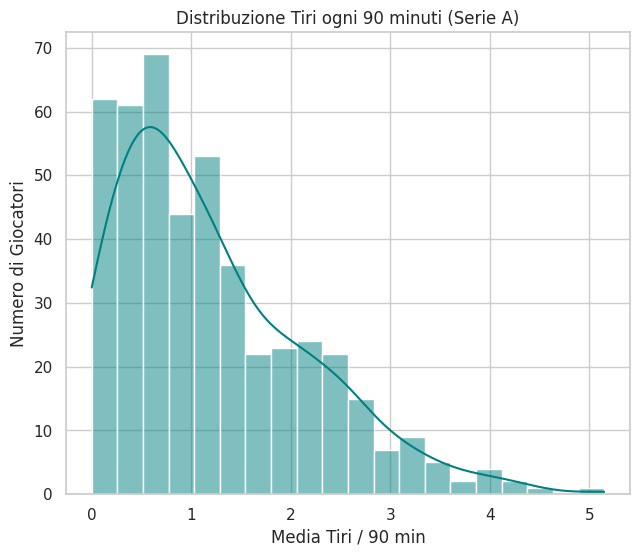

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

# Settiamo lo stile generale
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 6))

# GRAFICO 1: Distribuzione dei tiri nella Serie A
# Ci aiuta a capire qual è la media reale del campionato
plt.subplot(1, 2, 1)
sns.histplot(df_clean['Sh/90'], bins=20, kde=True, color="teal")
plt.title('Distribuzione Tiri ogni 90 minuti (Serie A)')
plt.xlabel('Media Tiri / 90 min')
plt.ylabel('Numero di Giocatori')





# GRAFICO 2: Top 15 Tiratori della Stagione

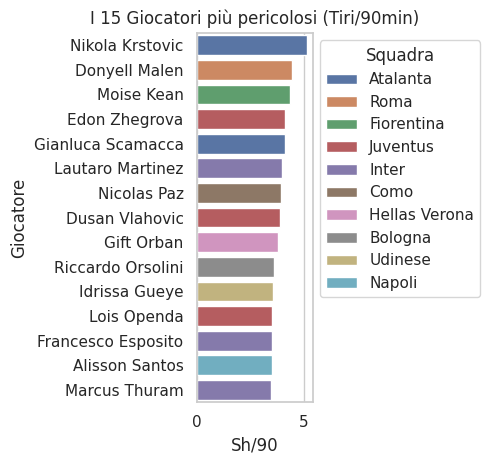

In [65]:

# GRAFICO 2: Top 15 Tiratori della Stagione
# Identifichiamo i profili più pericolosi
plt.subplot(1, 2, 2)
top_15 = df_clean.sort_values(by='Sh/90', ascending=False).head(15)
sns.barplot(data=top_15, x='Sh/90', y='Giocatore', hue='Squadra', dodge=False)
plt.title('I 15 Giocatori più pericolosi (Tiri/90min)')
plt.legend(title='Squadra', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

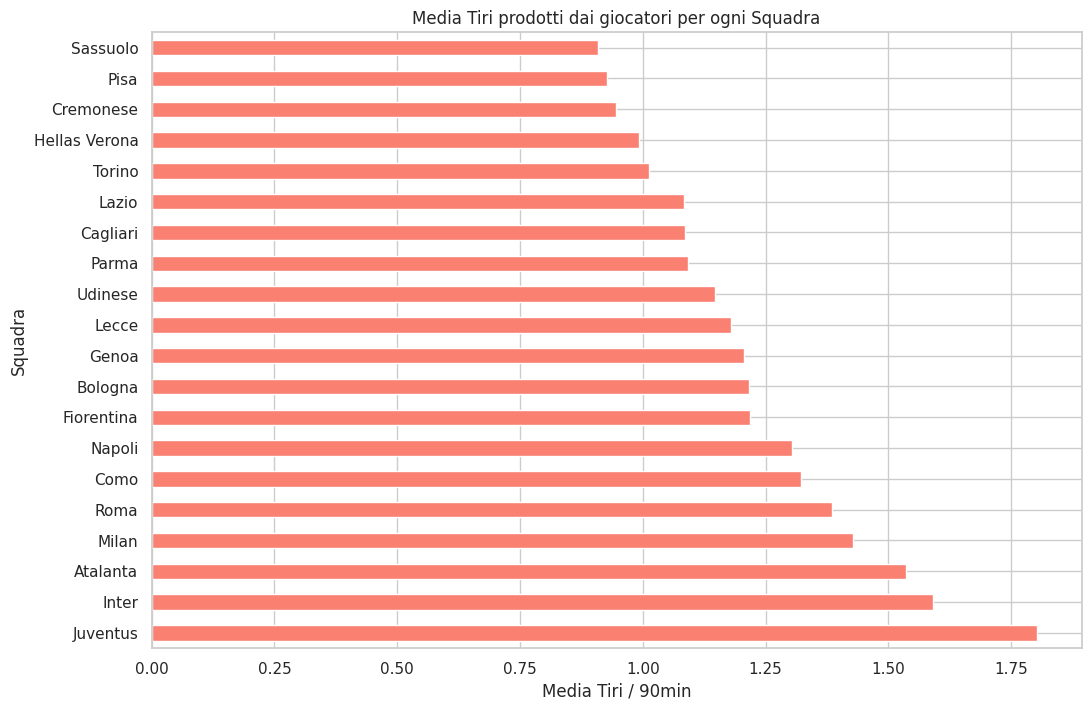

In [66]:
# Raggruppiamo per squadra e vediamo chi produce più tiri mediamente
media_squadre = df_clean.groupby('Squadra')['Sh/90'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
media_squadre.plot(kind='barh', color='salmon')
plt.title('Media Tiri prodotti dai giocatori per ogni Squadra')
plt.xlabel('Media Tiri / 90min')
plt.show()


# Efficienza vs Volume (Scatter Plot)
Questo grafico mette in relazione quanti tiri fa un giocatore (Sh/90) con quanti gol segna effettivamente (Gls).
In alto a destra: I "Top Player" (tirano tanto e segnano tanto).
In basso a destra: I "Sprecatori" (tirano tanto ma segnano poco).

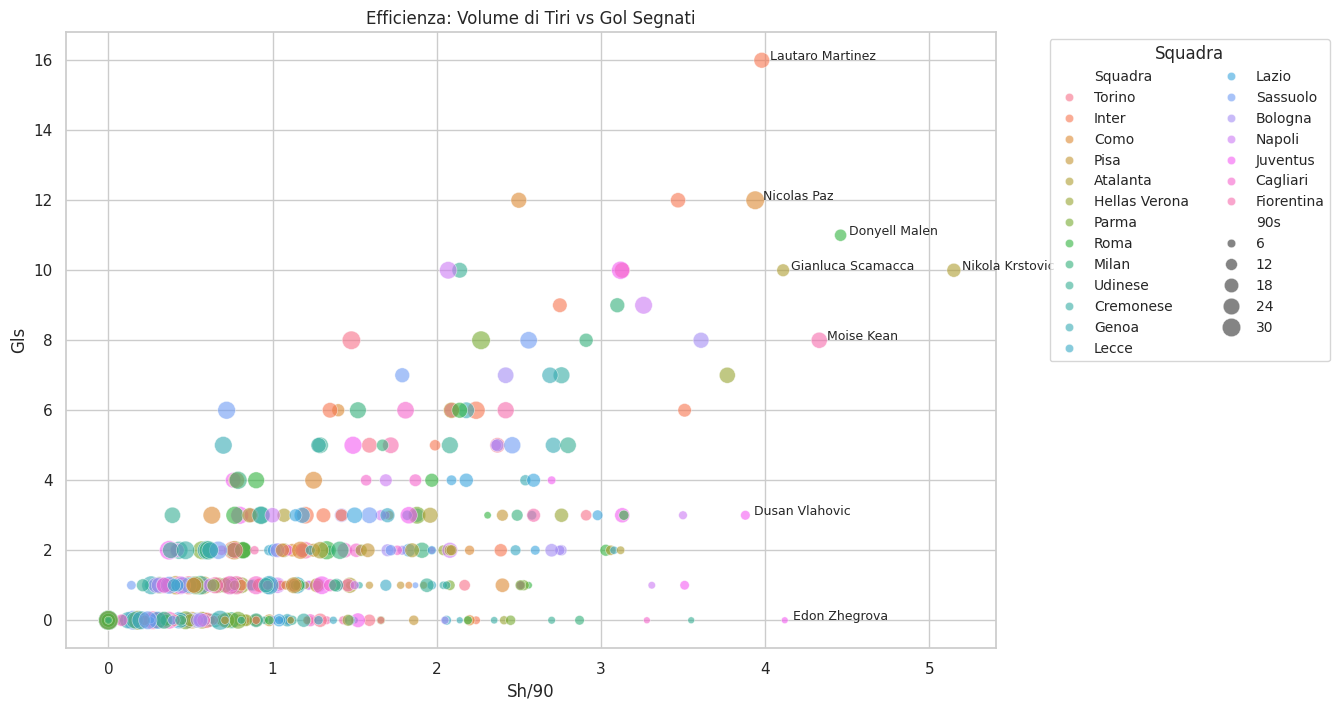

In [67]:
plt.figure(figsize=(12, 8))
df_clean['Gls'] = pd.to_numeric(df_clean['Gls'], errors='coerce')

# Usiamo 'hue' per la squadra e 'style' opzionale per differenziare meglio
sns.scatterplot(data=df_clean, x='Sh/90', y='Gls', hue='Squadra', size='90s', sizes=(20, 200), alpha=0.6)

# Annotazione automatica dei nomi per i primi 8 tiratori
top_8 = df_clean.sort_values(by='Sh/90', ascending=False).head(8)
for i in range(len(top_8)):
    plt.text(top_8.iloc[i]['Sh/90']+0.05, top_8.iloc[i]['Gls'], top_8.iloc[i]['Giocatore'], fontsize=9)

plt.title('Efficienza: Volume di Tiri vs Gol Segnati')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Squadra', fontsize='small', ncol=2)
plt.show()


# "Heatmap" della Pericolosità per Squadra
Questo grafico mostra graficamente quali squadre hanno i giocatori che occupano le posizioni più alte per volume di tiro.

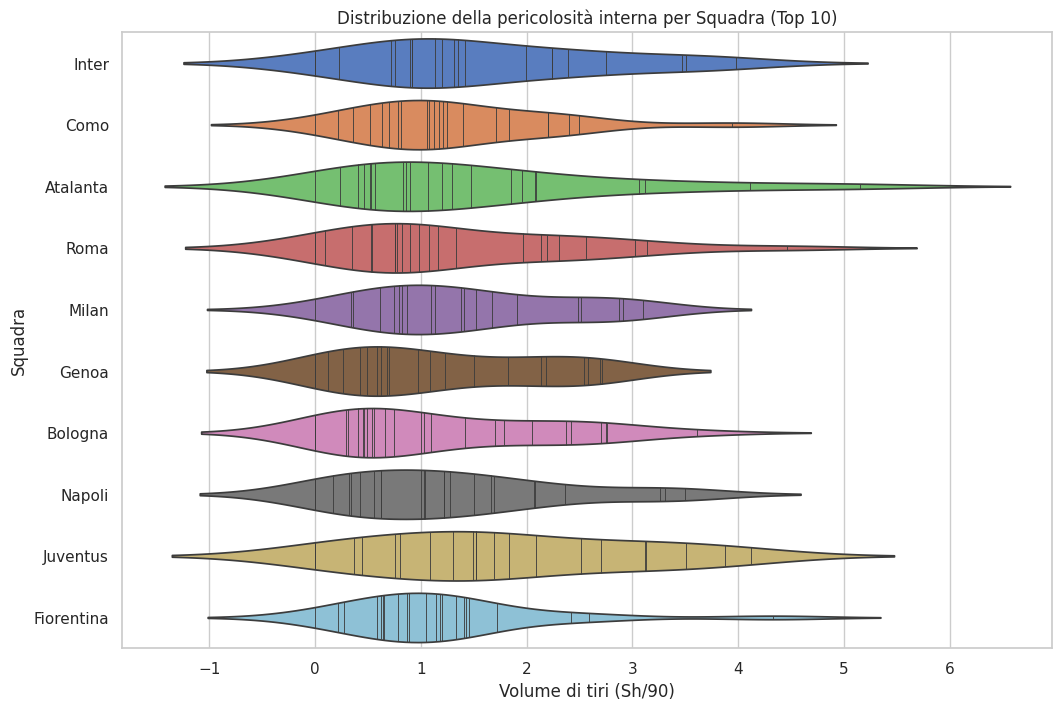

In [68]:
# Selezioniamo le 10 squadre con la media tiri più alta
top_squadre = df_clean.groupby('Squadra')['Sh/90'].mean().sort_values(ascending=False).head(10).index
df_top_squadre = df_clean[df_clean['Squadra'].isin(top_squadre)]

plt.figure(figsize=(12, 8))

# Assegniamo 'Squadra' a 'hue' come richiesto dalle nuove versioni
sns.violinplot(data=df_top_squadre, x='Sh/90', y='Squadra', hue='Squadra',
               inner="stick", palette="muted", legend=False)

plt.title('Distribuzione della pericolosità interna per Squadra (Top 10)')
plt.xlabel('Volume di tiri (Sh/90)')
plt.show()



# Precisione al Tiro (Box Plot per Ruolo)
Possiamo vedere chi è più preciso tra Attaccanti (FW), Centrocampisti (MF) e Difensori (DF) usando la colonna SoT% (Percentuale di tiri in porta).

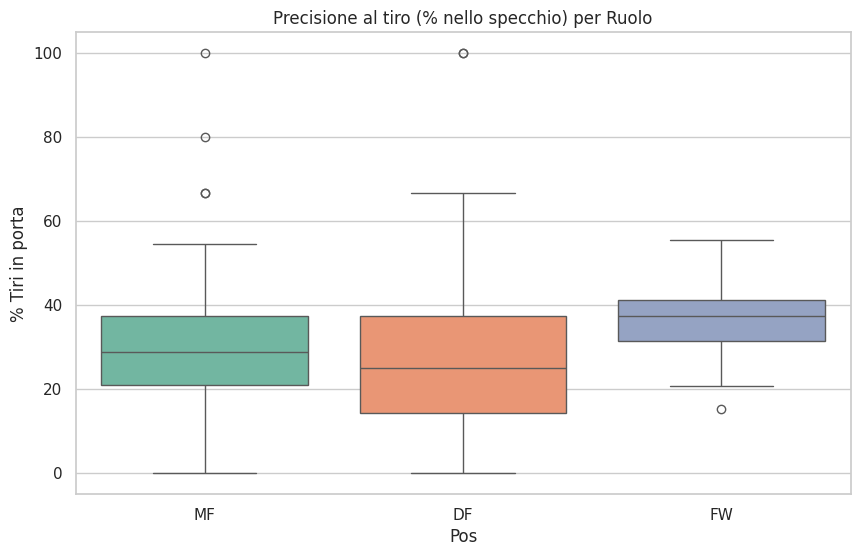

In [69]:
plt.figure(figsize=(10, 6))
df_clean['SoT%'] = pd.to_numeric(df_clean['SoT%'], errors='coerce')

# Assegniamo 'Pos' a 'hue' per evitare il Warning e togliamo la legenda inutile
sns.boxplot(data=df_clean[df_clean['Pos'].isin(['FW', 'MF', 'DF'])],
            x='Pos', y='SoT%', hue='Pos', palette='Set2', legend=False)

plt.title('Precisione al tiro (% nello specchio) per Ruolo')
plt.ylabel('% Tiri in porta')
plt.show()



In [70]:
import pandas as pd
import io
import re
from scipy.stats import poisson

# 1. recupero dati difese avversarie
dati_difesa_testo = """Squad	# Pl	90s	Gls	Sh	SoT	SoT%	Sh/90	SoT/90	G/Sh	G/SoT	PK	PKatt
vs Atalanta	24	34.0	31	399	132	33.1	11.74	3.88	0.08	0.23	1	3
vs Bologna	30	34.0	40	346	129	37.3	10.18	3.79	0.10	0.28	4	4
vs Cagliari	31	34.0	49	442	160	36.2	13.00	4.71	0.11	0.29	2	2
vs Como	24	34.0	28	315	111	35.2	9.26	3.26	0.08	0.22	4	5
vs Cremonese	31	34.0	49	559	185	33.1	16.44	5.44	0.08	0.25	3	5
vs Fiorentina	31	34.0	44	444	152	34.2	13.06	4.47	0.09	0.26	5	6
vs Genoa	31	34.0	46	435	144	33.1	12.79	4.24	0.09	0.28	6	6
vs Hellas Verona	34	34.0	53	438	136	31.1	12.88	4.00	0.12	0.38	2	4
vs Inter	25	34.0	31	309	98	31.7	9.09	2.88	0.09	0.28	4	4
vs Juventus	27	34.0	27	352	92	26.1	10.35	2.71	0.07	0.28	1	3
vs Lazio	28	34.0	33	455	141	31.0	13.38	4.15	0.07	0.21	3	5
vs Lecce	30	34.0	45	429	142	33.1	12.62	4.18	0.10	0.29	4	6
vs Milan	26	34.0	26	379	119	31.4	11.15	3.50	0.06	0.18	5	8
vs Napoli	28	34.0	33	350	101	28.9	10.29	2.97	0.08	0.27	6	9
vs Parma	31	34.0	39	482	144	29.9	14.18	4.24	0.07	0.24	4	5
vs Pisa	34	34.0	60	506	155	30.6	14.88	4.56	0.11	0.35	5	6
vs Roma	29	34.0	29	341	129	37.8	10.03	3.79	0.08	0.22	1	1
vs Sassuolo	31	34.0	42	496	174	35.1	14.59	5.12	0.07	0.21	5	6
vs Torino	30	34.0	56	464	148	31.9	13.65	4.35	0.11	0.35	4	4
vs Udinese	29	34.0	45	450	133	29.6	13.24	3.91	0.09	0.29	6	0
"""

# 2. TRASFORMAZIONE (Uso sep='\t' ma con gestione robusta degli spazi)
df_difese_raw = pd.read_csv(io.StringIO(dati_difesa_testo), sep='\t')


if len(df_difese_raw.columns) < 3:
    df_difese_raw = pd.read_csv(io.StringIO(dati_difesa_testo), sep=r'\s{2,}', engine='python')

# 3. PULIZIA E CALCOLO
# Assicuriamoci che 'Sh' (Tiri subiti) e '90s' siano numeri
df_difese_raw['Sh'] = pd.to_numeric(df_difese_raw['Sh'], errors='coerce')
df_difese_raw['90s'] = pd.to_numeric(df_difese_raw['90s'], errors='coerce')

# Calcolo Tiri Subiti per 90 minuti
df_difese_raw['Sh_Subiti_90'] = df_difese_raw['Sh'] / df_difese_raw['90s']

# Indice di Permissività: 1.0 è la media. >1.0 = difesa debole, <1.0 = difesa forte
media_campionato = df_difese_raw['Sh_Subiti_90'].mean()
df_difese_raw['Indice_Difesa'] = df_difese_raw['Sh_Subiti_90'] / media_campionato

# Rimuoviamo il "vs " dai nomi delle squadre per poterle incrociare meglio dopo
df_difese_raw['Squad'] = df_difese_raw['Squad'].str.replace('vs ', '')

print(" Statistiche difensive pronte!")
display(df_difese_raw[['Squad', 'Sh_Subiti_90', 'Indice_Difesa']].sort_values(by='Indice_Difesa', ascending=False))


 Statistiche difensive pronte!


,Squad,Sh_Subiti_90,Indice_Difesa
4,Cremonese,16.441176,1.332380
15,Pisa,14.882353,1.206054
17,Sassuolo,14.588235,1.182219
14,Parma,14.176471,1.148850
18,Torino,13.647059,1.105947
10,Lazio,13.382353,1.084495
19,Udinese,13.235294,1.072578
5,Fiorentina,13.058824,1.058277
2,Cagliari,13.000000,1.053510
7,Hellas Verona,12.882353,1.043976


# Il "Ranking della Permissività"
Questo grafico mostra chiaramente quali squadre subiscono più tiri. È la mappa dei tuoi bersagli: più la barra è alta, più è probabile che un attaccante avversario faccia tiri.

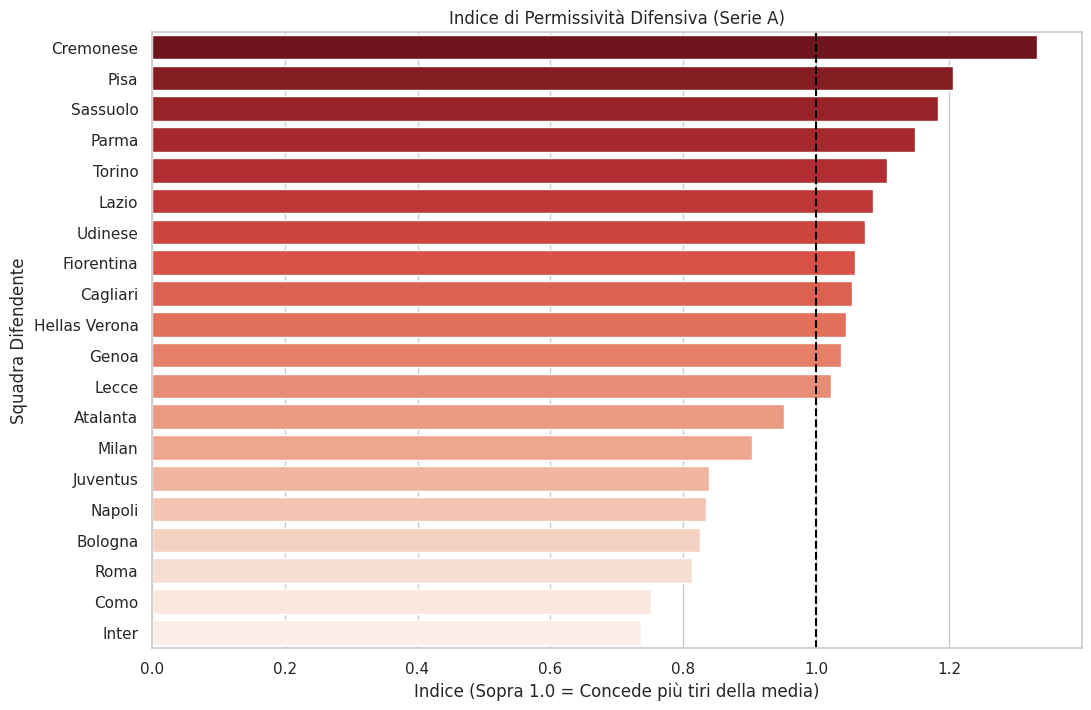

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ordiniamo le squadre dalla più debole alla più forte in difesa
df_plot_difese = df_difese_raw.sort_values(by='Indice_Difesa', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=df_plot_difese, x='Indice_Difesa', y='Squad', hue='Squad', palette='Reds_r', legend=False)

# Aggiungiamo una linea verticale sulla media (1.0)
plt.axvline(x=1.0, color='black', linestyle='--', label='Media Campionato')

plt.title('Indice di Permissività Difensiva (Serie A)')
plt.xlabel('Indice (Sopra 1.0 = Concede più tiri della media)')
plt.ylabel('Squadra Difendente')
plt.show()


# Analisi "Tiri Subiti vs Gol Subiti" (Efficienza Difensiva)
 Questo è un grafico avanzato (Scatter Plot). Ci dice se una squadra subisce tanti tiri ma ha un portiere bravo che para tutto, o se ogni tiro subito è un pericolo costante.
In alto a destra: Difese colabrodo (tanti tiri subiti, tanti gol).
In basso a sinistra: Difese d'acciaio.

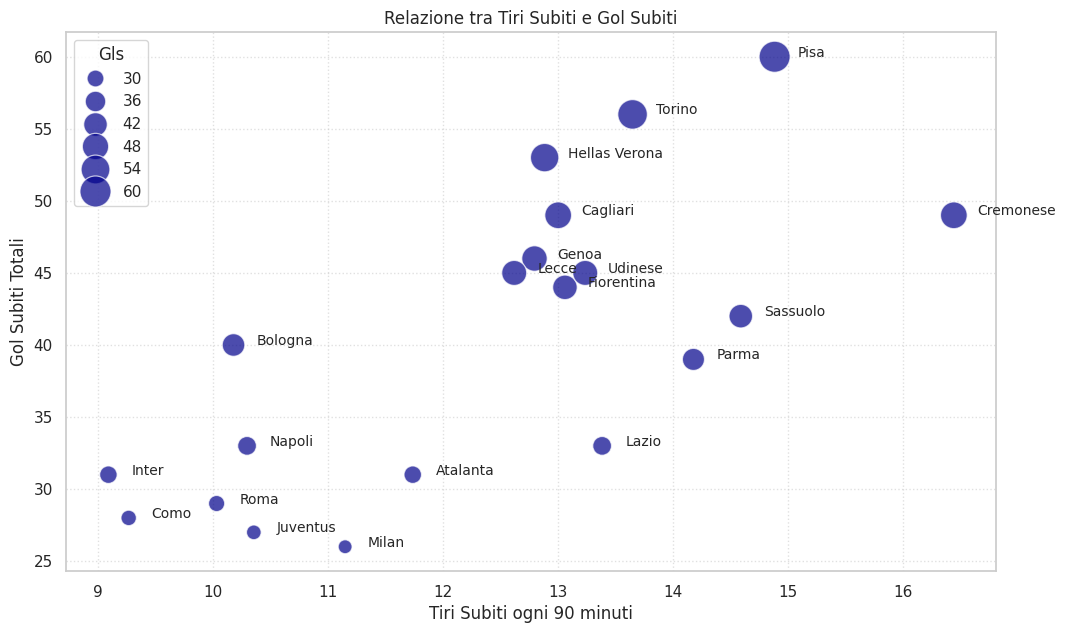

In [72]:
plt.figure(figsize=(12, 7))

# Assicuriamoci che i Gol Subiti (Gls) siano numerici
df_difese_raw['Gls'] = pd.to_numeric(df_difese_raw['Gls'], errors='coerce')

sns.scatterplot(data=df_difese_raw, x='Sh_Subiti_90', y='Gls', size='Gls', sizes=(100, 500), alpha=0.7, color='darkblue')

# Annotiamo i nomi delle squadre sui punti
for i in range(df_difese_raw.shape[0]):
    plt.text(df_difese_raw.Sh_Subiti_90.iloc[i]+0.2, df_difese_raw.Gls.iloc[i], df_difese_raw.Squad.iloc[i], fontsize=10)

plt.title('Relazione tra Tiri Subiti e Gol Subiti')
plt.xlabel('Tiri Subiti ogni 90 minuti')
plt.ylabel('Gol Subiti Totali')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


# Ultimi controlli del dataset finali:

In [73]:
# Controlliamo i nomi delle squadre nei due dataset prima di usare il Machine Learning
squadre_giocatori = set(df_clean['Squadra'].unique())
squadre_difese = set(df_difese_raw['Squad'].unique())

print("Squadre nel file Giocatori:", sorted(list(squadre_giocatori)))
print("\nSquadre nel file Difese:", sorted(list(squadre_difese)))

# Vediamo se ci sono discrepanze
mancanti = squadre_giocatori - squadre_difese
if mancanti:
    print(f"\n Attenzione! Queste squadre non coincidono: {mancanti}")
else:
    print("\n Perfetto! I nomi delle squadre coincidono in entrambi i file.")


Squadre nel file Giocatori: ['Atalanta', 'Bologna', 'Cagliari', 'Como', 'Cremonese', 'Fiorentina', 'Genoa', 'Hellas Verona', 'Inter', 'Juventus', 'Lazio', 'Lecce', 'Milan', 'Napoli', 'Parma', 'Pisa', 'Roma', 'Sassuolo', 'Torino', 'Udinese']

Squadre nel file Difese: ['Atalanta', 'Bologna', 'Cagliari', 'Como', 'Cremonese', 'Fiorentina', 'Genoa', 'Hellas Verona', 'Inter', 'Juventus', 'Lazio', 'Lecce', 'Milan', 'Napoli', 'Parma', 'Pisa', 'Roma', 'Sassuolo', 'Torino', 'Udinese']

 Perfetto! I nomi delle squadre coincidono in entrambi i file.


# Aggiunta del fattore campo
 si integra come un moltiplicatore correttivo della media base. Nello sport e come abbiamo visto nell altro mio progetto di data science (SULL'ANALISI DEL FATTORE CAMPO IN SERIE A), le statistiche confermano che giocare in casa aumenta la produzione offensiva di circa il 10-15%, mentre giocare in trasferta la penalizza.


In [74]:
from scipy.stats import poisson

def calcola_probabilita_campo(nome_giocatore, nome_avversario, soglia_tiri=2, dove_gioca='casa'):
    # 1. Troviamo il giocatore nel tuo database
    g_res = df[df['Giocatore'].str.contains(nome_giocatore, case=False)]
    if g_res.empty:
        print(" Giocatore non trovato!")
        return
    p = g_res.iloc[0] # Prendiamo il giocatore trovato

    # 2. Troviamo la difesa nel tuo database 'Against'
    d_res = df_difese_raw[df_difese_raw['Squad'].str.contains(nome_avversario, case=False)]
    indice_difesa = d_res['Indice_Difesa'].iloc[0] if not d_res.empty else 1.0

    # 3. APPLICHIAMO IL FATTORE CAMPO
    # In casa +12% di tiri, in trasferta -12%
    moltiplicatore_campo = 1.12 if dove_gioca.lower() == 'casa' else 0.88

    # 4. CALCOLO MEDIA FINALE (Lambda)
    media_attesa = p['Sh/90'] * indice_difesa * moltiplicatore_campo

    # 5. CALCOLO PERCENTUALE (Poisson)
    prob = (1 - poisson.cdf(soglia_tiri - 1, media_attesa)) * 100

    print(f"--- ANALISI {dove_gioca.upper()} ---")
    print(f"{p['Giocatore']} vs {nome_avversario}")
    print(f"Media attesa: {media_attesa:.2f} tiri")
    print(f"Probabilità di almeno {soglia_tiri} tiri: {prob:.2f}%")

# --- PROVA IL MODELLO ---
# Esempio: Vlahovic fuori casa contro il Lecce
calcola_probabilita_campo("Vla", "Lecce", soglia_tiri=3, dove_gioca="trasferta")



--- ANALISI TRASFERTA ---
Dusan Vlahovic vs Lecce
Media attesa: 3.49 tiri
Probabilità di almeno 3 tiri: 67.75%


# La Funzione Predittiva Definitiva
Questa funzione calcola la probabilità "reale" incrociando i tiri del giocatore, la forza della difesa e il fattore campo.

---  REPORT DATA SCIENCE: Dusan Vlahovic ---
Match: Juventus vs Lecce (CASA)
Media attesa: 4.44 tiri
----------------------------------------
Probabilità di almeno 1 tiri: 98.82%
Probabilità di almeno 2 tiri: 93.60%
Probabilità di almeno 3 tiri: 82.00%
Probabilità di almeno 4 tiri: 64.81%


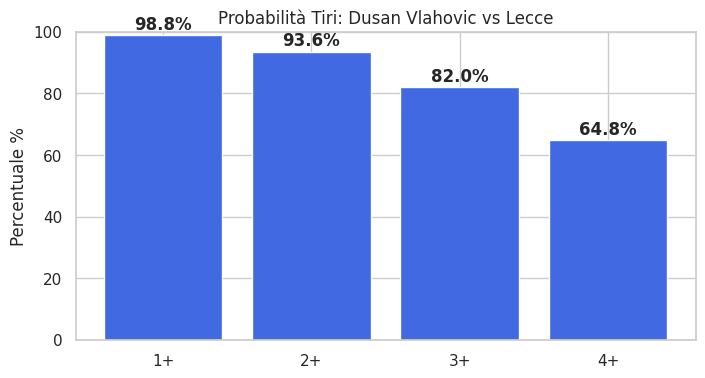

In [75]:
from scipy.stats import poisson
import matplotlib.pyplot as plt

def report_predittivo_finale(nome_parziale, nome_avversario, dove_gioca='casa'):
    # 1. Ricerca Giocatore
    g_res = df[df['Giocatore'].str.contains(nome_parziale, case=False)]
    if g_res.empty:
        print(f" '{nome_parziale}' non trovato!")
        return
    p = g_res.iloc[0]

    # 2. Ricerca Difesa
    d_res = df_difese_raw[df_difese_raw['Squad'].str.contains(nome_avversario, case=False)]
    indice_d = d_res['Indice_Difesa'].iloc[0] if not d_res.empty else 1.0

    # 3. Fattore Campo (Casa +12%, Trasferta -12%)
    molt_campo = 1.12 if dove_gioca.lower() == 'casa' else 0.88

    # 4. Calcolo Lambda Finale
    lambda_match = p['Sh/90'] * indice_d * molt_campo

    # --- VISUALIZZAZIONE RISULTATI ---
    print(f"---  REPORT DATA SCIENCE: {p['Giocatore']} ---")
    print(f"Match: {p['Squadra']} vs {nome_avversario} ({dove_gioca.upper()})")
    print(f"Media attesa: {lambda_match:.2f} tiri")
    print("-" * 40)

    soglie = [1, 2, 3, 4]
    probabilita = []

    for s in soglie:
        prob = (1 - poisson.cdf(s - 1, lambda_match)) * 100
        probabilita.append(prob)
        print(f"Probabilità di almeno {s} tiri: {prob:.2f}%")

    # --- GRAFICO DELLA PROBABILITÀ ---
    plt.figure(figsize=(8, 4))
    plt.bar([str(s)+"+" for s in soglie], probabilita, color='royalblue')
    plt.title(f"Probabilità Tiri: {p['Giocatore']} vs {nome_avversario}")
    plt.ylabel("Percentuale %")
    plt.ylim(0, 100)
    for i, v in enumerate(probabilita):
        plt.text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold')
    plt.show()

# --- PROVA FINALE ---
report_predittivo_finale("Vla", "Lecce", dove_gioca="casa")


# CELLA INTERATTIVA DI ANALISI:

⚽ CONFIGURAZIONE MATCH ⚽
------------------------------
Inserisci il nome del giocatore (es. Vla): vlahovic
Inserisci la squadra contro cui gioca (es. Lecce): lecce
Gioca in casa o trasferta? (scrivi 'casa' o 'trasferta'): casa

... Elaborazione dati in corso ...

---  REPORT DATA SCIENCE: Dusan Vlahovic ---
Match: Juventus vs lecce (CASA)
Media attesa: 4.44 tiri
----------------------------------------
Probabilità di almeno 1 tiri: 98.82%
Probabilità di almeno 2 tiri: 93.60%
Probabilità di almeno 3 tiri: 82.00%
Probabilità di almeno 4 tiri: 64.81%


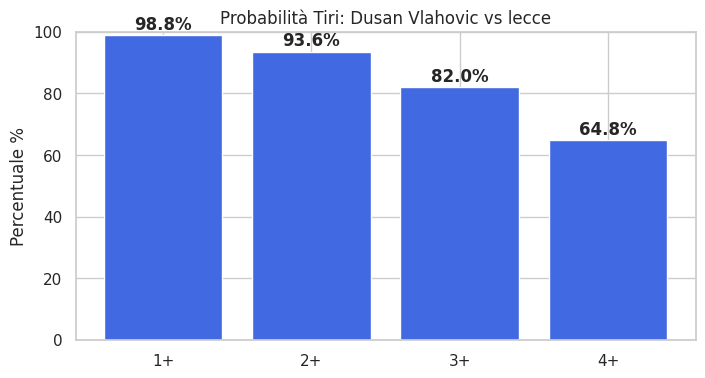

In [76]:

print("⚽ CONFIGURAZIONE MATCH ⚽")
print("-" * 30)

# Input dell'utente
giocatore_input = input("Inserisci il nome del giocatore (es. Vla): ")
avversario_input = input("Inserisci la squadra contro cui gioca (es. Lecce): ")
campo_input = input("Gioca in casa o trasferta? (scrivi 'casa' o 'trasferta'): ")

# Controllo tiri (puoi anche chiedere questo come input se vuoi)
target_tiri = 2

print("\n... Elaborazione dati in corso ...\n")

# Chiamata alla funzione (usiamo quella definita nello step precedente)
# Assicurati di aver runnato la cella della funzione 'report_predittivo_finale' prima di questa
try:
    report_predittivo_finale(giocatore_input, avversario_input, dove_gioca=campo_input)
except NameError:
    print(" Errore: Non hai ancora definito la funzione 'report_predittivo_finale'.")
    print("Copia e runna la cella dello Step Finale prima di usare questa interfaccia.")
